In [11]:
using MKL, JLD2, MAT, TOML, LinearAlgebra, MPSKit, Random, TensorKit, CairoMakie, Polynomials, KrylovKit, MPSKitModels
using Printf
using LaTeXStrings
BLAS.set_num_threads(16)

# spin operators
function spin_operators()
    PS = Vect[SU2Irrep]((1 // 2) => 1)

    # Sf ⋅ Sf
    SS2 = TensorMap(zeros, ComplexF64, PS * PS, PS * PS)
    blocks(SS2)[Irrep[SU₂](0)] .= -0.75
    blocks(SS2)[Irrep[SU₂](1)] .= 0.25

    S2 = TensorMap(zeros, ComplexF64, PS, PS)
    blocks(S2)[Irrep[SU₂](1 // 2)] .= 0.75

    Schi = TensorMap(zeros, ComplexF64, PS * PS * PS, PS * PS * PS)
    blocks(Schi)[Irrep[SU₂](1 // 2)] .= [0.0+0.0im 0.0-1.0im; 0.0+1.0im 0.0+0.0im] .* sqrt(3)/4

    return SS2, S2, Schi
end


function correlation_matrix_nobd(st, Ny)
    SS1, S2, Schi = spin_operators()
    N = Ny * Ny
    # @assert length(st) == N
    cms = []
    for s in 0:1
        Sij = zeros(Float64, N, N)
        for i in 1:N-1
            Sij[i, i+1:end] = real(correlator(st, SS1, 2*i-1+s, s+2*i+1:2:2*N)) 
        end
        S = Sij + Sij'
        for i in 1:N
            S[i, i] = real(expectation_value(st, 2*i-1+s => S2))
        end
        push!(cms, S)
    end
    return cms
end

function structure_factor_2d(correlations, Ny::Int, kx::Real, ky::Real)
    # correlations: Matrix of size (Nx*Ny) × (Nx*Ny) containing <Si Sj>
    # Nx, Ny: Lattice dimensions
    # kx, ky: Wave vector components
    a1 = [1.0, 0.0]
    a2 = [1.0/2, sqrt(3.0)/2]
    
    Sk = [0.0+0.0im, 0.0+0.0im] # Initialize as ComplexF64
    N = Ny * Ny 
    get_idx(ix, iy) = (ix - 1) * Ny + iy 

    for ix in 1:Ny
        for iy in 1:Ny
            i = get_idx(ix, iy)

            for jx in 1:Ny
                for jy in 1:Ny
                    j = get_idx(jx, jy)

                    dx = (ix - jx)
                    dy = (iy - jy)
                    rx = dx * a1[1] + dy * a2[1]
                    ry = dx * a1[2] + dy * a2[2]
                    phase = exp(im * (kx * rx + ky * ry))

                    Sk[1] += phase * correlations[1][i, j]
                    Sk[2] += phase * correlations[2][i, j]
                end
            end
        end
    end

    return real(Sk) ./ N  # Normalize by system size
end

# Create a grid of k-points
function compute_structure_factor_grid(correlations, Ny::Int, nkx::Int=20, nky::Int=20)
    kx_range = range(-2π, 2π, length=nkx)
    ky_range = range(-2π, 2π, length=nky)

    SqA = zeros(Float64, nkx, nky)
    SqB = zeros(Float64, nkx, nky)

    for (i, kx) in enumerate(kx_range)
        for (j, ky) in enumerate(ky_range)
            SqA[i, j], SqB[i, j] = structure_factor_2d(correlations, Ny, kx, ky)
        end
    end

    return kx_range, ky_range, SqA, SqB
end


function positions(Nx, Ny)
    a1 = [1.0, 0.0]
    a2 = [1.0/2, sqrt(3)/2]
    q = (a1 + a2)/3

    positions = Vector{Vector{Float64}}()

    for ix in 1:Nx+1
        for iy in 1:Ny
            n_x = ix - 1
            n_y = iy - 1
            
            r_origin = n_x .* a1 .+ n_y .* a2
            
            push!(positions, r_origin)
            push!(positions, r_origin .+ q)
        end
    end
    
    return positions
end

function NNbonds_inf(Nx, Ny, yperiodic=true)
    bonds = []
    get_idx(ix, iy, s) = (ix - 1) * (2 * Ny) + (iy - 1) * 2 + 1 + s

    for ix in 1:Nx
        for iy in 1:Ny
            # Site indices for current unit cell
            idxA = get_idx(ix, iy, 0)
            idxB = get_idx(ix, iy, 1)
            
            # 1. Intracell bond (A connects to B in same cell)
            push!(bonds, (idxA, idxB))
            
            # 2. Intercell Y bond: B(x, y) connects to A(x, y+1)
            if iy < Ny
                idxA_nextY = get_idx(ix, iy + 1, 0)
                push!(bonds, (idxB, idxA_nextY))
            elseif yperiodic
                idxA_nextY = get_idx(ix, 1, 0)
                push!(bonds, (idxA_nextY, idxB))
            end
            
            # 3. Intercell X bond: B(x, y) connects to A(x+1, y)
            if ix <= Nx
                idxA_nextX = get_idx(ix + 1, iy, 0)
                push!(bonds, (idxB, idxA_nextX))
            end
        end
    end
    if yperiodic
        @assert length(bonds) == 3 * Nx * Ny "length(bonds) = $(length(bonds)), not $(3 * Nx * Ny)"
    end
    return bonds
end

function NNNbonds_inf(Nx, Ny, yperiodic=true)
    bonds = Tuple{Int, Int}[]
    get_idx(ix, iy, s) = (ix - 1) * (2 * Ny) + (iy - 1) * 2 + 1 + s

    for ix in 1:Nx
        for iy in 1:Ny
            idxA = get_idx(ix, iy, 0)
            idxB = get_idx(ix, iy, 1)

            if iy < Ny
                push!(bonds, (idxA, get_idx(ix, iy + 1, 0)))
                push!(bonds, (idxB, get_idx(ix, iy + 1, 1)))
            elseif yperiodic
                push!(bonds, (idxA, get_idx(ix, 1, 0)))
                push!(bonds, (idxB, get_idx(ix, 1, 1)))
            end

            push!(bonds, (idxA, get_idx(ix + 1, iy, 0)))
            push!(bonds, (idxB, get_idx(ix + 1, iy, 1)))

            if iy > 1
                push!(bonds, (idxA, get_idx(ix + 1, iy - 1, 0)))
                push!(bonds, (idxB, get_idx(ix + 1, iy - 1, 1)))
            elseif yperiodic
                push!(bonds, (idxA, get_idx(ix + 1, Ny, 0)))
                push!(bonds, (idxB, get_idx(ix + 1, Ny, 1)))
            end
        end
    end

    if yperiodic
        @assert length(bonds) == 6 * Nx * Ny "length(bonds) = $(length(bonds)), not $(6 * Nx * Ny)"
    end
    return bonds
end

function plot_bonds_pub(bond_values::AbstractVector, Nx, Ny;
                        yperiodic=true, show_values=true,
                        subtract_mean=true, max_thickness=10.0,
                        min_thickness=1.0, text_digits=3,
                        font_size=14, site_markersize=8,
                        colormap=:RdBu, figure_size=(1000, 650))
    pos = positions(Nx, Ny)
    bonds = NNbonds_inf(Nx, Ny, yperiodic)
    vals = Float64.(real.(bond_values))
    @assert length(vals) == length(bonds) "length(bond_values) = $(length(vals)), but length(bonds) = $(length(bonds))"

    if subtract_mean
        vals = vals .- sum(vals) / length(vals)
    end

    min_val, max_val = extrema(vals)
    if min_val ≈ max_val
        min_val -= 0.1
        max_val += 0.1
    end
    crange = (-1e-3, 1e-3) #(min_val, max_val)

    abs_vals = abs.(vals)
    max_abs = maximum(abs_vals)
    if max_abs == 0.0
        max_abs = 1.0
    end
    linewidths = min_thickness .+ (max_thickness - min_thickness) .* (abs_vals ./ max_abs)

    segments = Point2f[]
    midpoints = Point2f[]
    labels = String[]
    for (k, (i, j)) in enumerate(bonds)
        x1, y1 = pos[i][1], pos[i][2]
        x2, y2 = pos[j][1], pos[j][2]
        push!(segments, Point2f(x1, y1))
        push!(segments, Point2f(x2, y2))
        push!(midpoints, Point2f((x1 + x2) / 2, (y1 + y2) / 2))
        push!(labels, @sprintf("%.*f", text_digits, vals[k]))
    end

    fig = Figure(size=figure_size, backgroundcolor=:white, fonts=(; regular="Arial"))
    ax = Axis(fig[1, 1], aspect=DataAspect())
    hidedecorations!(ax)
    hidespines!(ax)

    p_bonds = linesegments!(ax, segments;
        color=repeat(vals, inner=2),
        colormap=colormap,
        colorrange=crange,
        linewidth=repeat(linewidths, inner=2),
        linecap=:round,
        alpha=0.8)

    if show_values
        text!(ax, midpoints;
            text=labels,
            align=(:center, :center),
            fontsize=font_size,
            color=:black,
            glowwidth=4.0,
            glowcolor=(:white, 0.9))
    end

    scatter!(ax, first.(pos), last.(pos); color=:black, markersize=site_markersize)

    label = subtract_mean ? "Bond expectation - mean" : "Bond expectation value"
    Colorbar(fig[1, 2], p_bonds; label=label)

    return fig
end

function plot_bonds_pub(st, Nx, Ny; yperiodic=true, kwargs...)
    SS1, S2, Schi = spin_operators()
    bonds = NNbonds_inf(Nx, Ny, yperiodic)
    bond_values = [real(correlator(st, SS1, i, j)) for (i, j) in bonds]
    return plot_bonds_pub(bond_values, Nx, Ny; yperiodic=yperiodic, kwargs...)
end

function plot_bonds_nnn_pub(nn_values::AbstractVector, nnn_values::AbstractVector, Nx, Ny;
                               yperiodic=true, show_values=true,
                               subtract_mean=false, max_thickness=10.0,
                               min_thickness=1.0, text_digits=3,
                               font_size=14, site_markersize=8,
                               nn_text_color=:red, nnn_text_color=:blue,
                               colormap=:RdBu, figure_size=(1000, 650))
    pos = positions(Nx, Ny)
    nn_bonds = NNbonds_inf(Nx, Ny, yperiodic)
    nnn_bonds = NNNbonds_inf(Nx, Ny, yperiodic)
    nn_vals = Float64.(real.(nn_values))
    nnn_vals = Float64.(real.(nnn_values))
    @assert length(nn_vals) == length(nn_bonds) "length(nn_values) = $(length(nn_vals)), but length(nn_bonds) = $(length(nn_bonds))"
    @assert length(nnn_vals) == length(nnn_bonds) "length(nnn_values) = $(length(nnn_vals)), but length(nnn_bonds) = $(length(nnn_bonds))"

    if subtract_mean
        nn_vals = nn_vals .- sum(nn_vals) / length(nn_vals)
        nnn_vals = nnn_vals .- sum(nnn_vals) / length(nnn_vals)
    end

    min_val, max_val = extrema(nn_vals)
    if min_val ≈ max_val
        min_val -= 0.1
        max_val += 0.1
    end
    crange = (min_val, -min_val)

    # crange = (-1e-3, 1e-3)

    abs_vals = abs.(vcat(nn_vals, nnn_vals))
    max_abs = maximum(abs_vals)
    if max_abs == 0.0
        max_abs = 1.0
    end
    nn_linewidths = min_thickness .+ (max_thickness - min_thickness) .* (abs.(nn_vals) ./ max_abs)
    nnn_linewidths = min_thickness .+ (max_thickness - min_thickness) .* (abs.(nnn_vals) ./ max_abs)

    function bond_plot_data(bonds, vals)
        segments = Point2f[]
        midpoints = Point2f[]
        labels = String[]
        for (k, (i, j)) in enumerate(bonds)
            x1, y1 = pos[i][1], pos[i][2]
            x2, y2 = pos[j][1], pos[j][2]
            push!(segments, Point2f(x1, y1))
            push!(segments, Point2f(x2, y2))
            push!(midpoints, Point2f((x1 + x2) / 2, (y1 + y2) / 2))
            push!(labels, @sprintf("%.*f", text_digits, vals[k]))
        end
        return segments, midpoints, labels
    end

    nn_segments, nn_midpoints, nn_labels = bond_plot_data(nn_bonds, nn_vals)
    nnn_segments, nnn_midpoints, nnn_labels = bond_plot_data(nnn_bonds, nnn_vals)

    fig = Figure(size=figure_size, backgroundcolor=:white, fonts=(; regular="Arial"))
    ax = Axis(fig[1, 1], aspect=DataAspect())
    hidedecorations!(ax)
    hidespines!(ax)

    # Draw NNN bonds first so the solid NN bonds and sites remain visible on top.
    p_nnn = linesegments!(ax, nnn_segments;
        color=repeat(nnn_vals, inner=2),
        colormap=colormap,
        colorrange=crange,
        linewidth=repeat(nnn_linewidths, inner=2),
        linecap=:round,
        # linestyle=:dash,
        alpha=0.8)

    p_nn = linesegments!(ax, nn_segments;
        color=repeat(nn_vals, inner=2),
        colormap=colormap,
        colorrange=crange,
        linewidth=repeat(nn_linewidths, inner=2),
        linecap=:round,
        alpha=0.8)

    if show_values
        text!(ax, nn_midpoints;
            text=nn_labels,
            align=(:center, :center),
            fontsize=font_size,
            color=nn_text_color,
            glowwidth=4.0,
            glowcolor=(:white, 0.9))
        text!(ax, nnn_midpoints;
            text=nnn_labels,
            align=(:center, :center),
            fontsize=font_size,
            color=nnn_text_color,
            glowwidth=4.0,
            glowcolor=(:white, 0.9))
    end

    scatter!(ax, first.(pos), last.(pos); color=:black, markersize=site_markersize)

    lines!(ax, [NaN, NaN], [NaN, NaN]; color=:gray35, linewidth=3, label="NN")
    lines!(ax, [NaN, NaN], [NaN, NaN]; color=:gray35, linewidth=3,
        linestyle=:dash, label="NNN")
    axislegend(ax; position=:lt, framevisible=false)

    label = subtract_mean ? "Bond expectation - mean" : "Bond expectation value"
    Colorbar(fig[1, 2], p_nn; label=label)

    return fig
end

function plot_bonds_nnn_pub(st, Nx, Ny; yperiodic=true, kwargs...)
    SS1, S2, Schi = spin_operators()
    nn_bonds = NNbonds_inf(Nx, Ny, yperiodic)
    nnn_bonds = NNNbonds_inf(Nx, Ny, yperiodic)
    nn_values = [real(correlator(st, SS1, i, j)) for (i, j) in nn_bonds]
    nnn_values = [real(correlator(st, SS1, i, j)) for (i, j) in nnn_bonds]
    return plot_bonds_nnn_pub(nn_values, nnn_values, Nx, Ny; yperiodic=yperiodic, kwargs...)
end

"""
    bondCorrelations(state::InfiniteMPS, i::Int, Ny::Int): i is the first site in the bond

    Calculate a series of bond-bond correlators of a given InfiniteMPS in the infinite direction.
"""
function bondCorrelations(state::InfiniteMPS, i::Int, Ny::Int; shift=0)
    SS1, S2, Schi = spin_operators()
    @assert i < 2*Ny-1 "i must be less than Ny-1"
    
    S1234 = []
    connect = 0 # real(expectation_value(state, (1,2) => SS1))^2
    
    @plansor S12_l[-1; -3] := state.AC[i][4 5; 6] * state.AR[i+1][6 7; -3] * SS1[3 1; 5 7] * conj(state.AC[i][4 3; 2]) * conj(state.AR[i+1][2 1; -1])
    ctr = i + 2
    for k in 1:50
        j = i + Ny*2 * k + shift
        S12_l = S12_l * MPSKit.TransferMatrix(state.AR[ctr:(j - 1)])
        @plansor S4 = S12_l[-1; -3] * state.AR[j][-3 5; 6] * state.AR[j+1][6 7; 8] * SS1[3 1; 5 7] * conj(state.AR[j][-1 3; 2]) * conj(state.AR[j+1][2 1; 8])
        push!(S1234, real(S4)-connect)
        ctr = j
    end
    return S1234
end

"""
    chiralCorrelations(state::InfiniteMPS, i::Int, Ny::Int): i is the first site in the bond

    Calculate a series of chiral correlators of a given InfiniteMPS in the infinite direction.
"""
function chiralCorrelations(state::InfiniteMPS, i::Int, Ny::Int)
    SS1, S2, Schi = spin_operators()
    @assert i < 2*Ny-1 "i must be less than Ny-1"
    
    S123456 = []
    connect = 0 # real(expectation_value(state, (1,2,3) => Schi))^2
    
    @plansor S123_l[-1; -3] := state.AC[i][6 7; 8] * state.AR[i+1][8 9; 10] * state.AR[i+2][10 11; -3] * Schi[5 3 1; 7 9 11] * conj(state.AC[i][6 5; 4]) * conj(state.AR[i+1][4 3; 2]) * conj(state.AR[i+2][2 1; -1])
    ctr = i + 3
    for k in 1:50
        j = i + Ny*2 * k
        S123_l = S123_l * MPSKit.TransferMatrix(state.AR[ctr:(j - 1)])
        @plansor S6 = S123_l[-1; -3] * state.AR[i][-3 7; 8] * state.AR[i+1][8 9; 10] * state.AR[i+2][10 11; 6] * Schi[5 3 1; 7 9 11] * conj(state.AR[i][-1 5; 4]) * conj(state.AR[i+1][4 3; 2]) * conj(state.AR[i+2][2 1; 6])
        push!(S123456, real(S6)-connect)
        ctr = j
    end
    return S123456
end

function make_ham_inf_honeycomb(J1, J2, Nx, Ny, yperiodic=true)
    # SS2 = S_exchange(ComplexF64, U1Irrep; spin=1 // 2)
    SS2, _ = spin_operators()
    J3 = 0.0

    N = Nx * Ny * 2
    lat = InfiniteChain(N)

    NNbonds = []
    NNNbondsA = []
    NNNbondsB = []
    get_idx(ix, iy, s) = (ix - 1) * (2 * Ny) + (iy - 1) * 2 + 1 + s

    for ix in 1:Nx
        for iy in 1:Ny
            # Site indices for current unit cell
            idxA = get_idx(ix, iy, 0)
            idxB = get_idx(ix, iy, 1)
            
            # --- Nearest Neighbors ---
            # 1. Intracell bond (A connects to B in same cell)
            push!(NNbonds, (lat[idxA], lat[idxB]))
            
            # 2. Intercell Y bond: B(x, y) connects to A(x, y+1)
            if iy < Ny
                idxA_nextY = get_idx(ix, iy + 1, 0)
                push!(NNbonds, (lat[idxB], lat[idxA_nextY]))
            elseif yperiodic
                idxA_nextY = get_idx(ix, 1, 0)
                push!(NNbonds, (lat[idxB], lat[idxA_nextY]))
            end
            
            # 3. Intercell X bond: B(x, y) connects to A(x+1, y)
            # We use ix+1 directly. lat handles indices > N (mapping to next MPS unit cell)
            idxA_nextX = get_idx(ix + 1, iy, 0)
            push!(NNbonds, (lat[idxB], lat[idxA_nextX]))

            # --- Next Nearest Neighbors ---
            # 1. Intercell bond Y: (x, y) -> (x, y+1)
            if iy < Ny
                idxA_nextY = get_idx(ix, iy + 1, 0)
                idxB_nextY = get_idx(ix, iy + 1, 1) 
                push!(NNNbondsA, (lat[idxA], lat[idxA_nextY]))
                push!(NNNbondsB, (lat[idxB], lat[idxB_nextY])) 
            elseif yperiodic
                idxA_nextY = get_idx(ix, 1, 0)
                idxB_nextY = get_idx(ix, 1, 1)
                push!(NNNbondsA, (lat[idxA], lat[idxA_nextY]))
                push!(NNNbondsB, (lat[idxB], lat[idxB_nextY]))
            end
            
            # 2. Intercell bond X: (x, y) -> (x+1, y)
            idxA_nextX = get_idx(ix + 1, iy, 0)
            idxB_nextX = get_idx(ix + 1, iy, 1)
            push!(NNNbondsA, (lat[idxA], lat[idxA_nextX]))
            push!(NNNbondsB, (lat[idxB], lat[idxB_nextX]))

            # 3. Intercell bond Diagonal: (x, y) -> (x+1, y-1)
            if iy > 1
                idxA_diag = get_idx(ix + 1, iy - 1, 0)
                idxB_diag = get_idx(ix + 1, iy - 1, 1)
                push!(NNNbondsA, (lat[idxA], lat[idxA_diag]))
                push!(NNNbondsB, (lat[idxB], lat[idxB_diag]))
            elseif yperiodic
                idxA_diag = get_idx(ix + 1, Ny, 0)
                idxB_diag = get_idx(ix + 1, Ny, 1)
                push!(NNNbondsA, (lat[idxA], lat[idxA_diag]))
                push!(NNNbondsB, (lat[idxB], lat[idxB_diag]))
            end
        end
    end

    Hlist = [[LocalOperator(SS2, i, j) * J1 for (i, j) in NNbonds]..., 
             [LocalOperator(SS2, i, j) * J2 for (i, j) in NNNbondsA]..., 
             [LocalOperator(SS2, i, j) * J3 for (i, j) in NNNbondsB]...]

    return @mpoham sum(Hlist)
end

"""
    sortedTransferSpectrum(st; site=1, trunc=1e-15, tol=1e-15)

    Get the transfer spectrum of a given InfiniteMPS and sort the sectors by the maximum value of the spectrum.

    # Arguments
    - `site::Int=0`: mps index for multisite unit cells. Spectrum is computed for the bond between `site` and `site + 1`.
    - `trunc`: the threshold for truncating the maximum values.
    - `tol`: the tolerance for the transfer spectrum calculation.
"""
function sortedTransferSpectrum(st; mix=st, site=1, trunc=1e-15, tol=1e-15)
    tol = tol
    Vl = left_virtualspace(st, site)
    secs = collect(blocksectors(fuse(Vl, dual(Vl))))[1:min(end, 10)]
    spect = [transfer_spectrum(st, below=mix, sector=Vi, tol=tol) for Vi in secs]

    # Calculate the maximum of each element in spect and Trancate max_values below trunc
    max_values = [maximum(abs.(s)) for s in spect]
    max_values = max_values[max_values.>trunc]

    # Get the sorting indices
    indices = sortperm(max_values)

    # Sort secs and spect
    secs_sorted = secs[indices]
    spect_sorted = spect[indices]

    return reverse(secs_sorted), reverse(spect_sorted)
end

function correlation_matrix_full(st, Ny)
    # Get operators (assuming these are your custom ITensors helpers)
    SS1, S2, Schi = spin_operators() 
    
    # N is the number of unit cells; N_total is the total number of sites
    N_uc = Ny * Ny 
    N_total = 2 * N_uc 
    
    Sij = zeros(Float64, N_total, N_total)
    
    # Compute the upper triangle: <Si . Sj> for all pairs i, j
    for i in 1:N_total-1
        # ITensors.correlator handles the string of operators for you
        Sij[i, i+1:end] = real(correlator(st, SS1, i, i+1:N_total))
    end
    
    # Fill the symmetric lower triangle
    S = Sij + Sij'
    
    # Add diagonal terms <Si . Si>
    for i in 1:N_total
        S[i, i] = real(expectation_value(st, i => S2))
    end
    
    return S
end

function structure_factor_honeycomb(correlations, Ny::Int, kx::Real, ky::Real)
    # 1. Define Geometry (matching your plot's axes)
    a1 = [1.0, 0.0]
    a2 = [0.5, sqrt(3.0)/2.0]
    # Standard basis vector for sublattice B relative to A
    delta_B = (a1 + a2) / 3.0 
    
    N_uc = Ny * Ny
    N_total = 2 * N_uc
    
    # 2. Precompute positions for every site 1..N_total
    # We assume site mapping: 2*i-1 = Sublattice A, 2*i = Sublattice B
    pos = Vector{Vector{Float64}}(undef, N_total)
    for i_uc in 1:N_uc
        # Inverse of get_idx: map unit cell index back to (ix, iy)
        iy = (i_uc - 1) % Ny + 1
        ix = div(i_uc - 1, Ny) + 1
        
        R_origin = (ix - 1) * a1 + (iy - 1) * a2
        
        pos[2*i_uc - 1] = R_origin           # Sublattice A
        pos[2*i_uc]     = R_origin + delta_B # Sublattice B
    end

    # 3. Sum over all pairs
    Sk = 0.0 + 0.0im
    for i in 1:N_total
        ri = pos[i]
        for j in 1:N_total
            rj = pos[j]
            # Calculating phase using the vector difference
            phase = exp(im * (kx * (ri[1] - rj[1]) + ky * (ri[2] - rj[2])))
            Sk += phase * correlations[i, j]
        end
    end

    # Normalize by total number of sites
    return real(Sk) / N_total 
end

function compute_structure_factor_grid_honeycomb(correlations, Ny::Int, nkx::Int=20, nky::Int=20)
    kx_range = range(-3π, 3π, length=nkx)
    ky_range = range(-3π, 3π, length=nky)

    SqA = zeros(Float64, nkx, nky)

    for (i, kx) in enumerate(kx_range)
        for (j, ky) in enumerate(ky_range)
            SqA[i, j] = structure_factor_honeycomb(correlations, Ny, kx, ky)
        end
    end

    return kx_range, ky_range, SqA
end

function logTransferPlot(st; mix=st, site=1, secNum=4, num_vals=10, secs=nothing, spect=nothing, title=nothing)
    if secs === nothing || spect === nothing
        secs, spect = sortedTransferSpectrum(st; mix=mix, site=site)
    end

    secNum = min(secNum, length(secs))
    ssecs = reverse(secs[1:secNum])
    sspect = reverse(spect[1:secNum])

    # Deeper, more distinct "Tol-like" bright/dark palette for publication
    cb_colors = [
        RGBf( 68/255, 119/255, 170/255),  # deep blue
        RGBf(238/255, 102/255, 119/255),  # reddish-pink
        RGBf( 34/255, 136/255,  51/255),  # nature green
        RGBf(204/255, 187/255,  68/255),  # sandy gold
        RGBf(102/255, 204/255, 238/255),  # cyan
        RGBf(170/255,  51/255, 119/255),  # purple
        RGBf(187/255, 187/255, 187/255)   # grey
    ]
    
    # Makie marker types
    marker_types = [:circle, :diamond, :rect, :utriangle, :dtriangle, :star5, :hexagon]

    del = -log(abs(spect[1][num_vals]))
    
    # Figure setup
    set_theme!()
    fig = Figure(size = (600, 400), fonts = (; regular = "Computer Modern", bold = "Computer Modern"))
    
    # Custom x-ticks
    xticks_vals = collect(0:π/3:2π)
    xticks_labels = [L"0", L"\pi/3", L"2\pi/3", L"\pi", L"4\pi/3", L"5\pi/3", L"2\pi"]

    # Axis setup (Fixed tick alignment)
    ax = Axis(fig[1, 1],
        xlabel = L"\theta", 
        ylabel = L"-\ln|\lambda|",
        title = isnothing(title) ? "" : title,                
        limits = (-0.1, 2π+0.1, -0.05 * del, 1.05 * del),
        xgridvisible = true,
        ygridvisible = true,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xticksvisible=true, yticksvisible=true,
        xticklabelsvisible=true, yticklabelsvisible=true,
        xtickalign = 1, # 1 corresponds to facing inwards
        ytickalign = 1, # 1 corresponds to facing inwards
        titlesize = 18,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 16,
        yticklabelsize = 16,
        xticks = (xticks_vals, xticks_labels)
    )

    for i in 1:secNum
        spi = sspect[i]
        theta = mod2pi.(angle.(spi))

        # Snap values that are approximately 2π to 0
        theta[isapprox.(theta, 2π, atol=1e-10)] .= 0.0
        
        eps   = -log.(abs.(spi))
        
        # Replace the problematic unicode subscript with an underscore
        label_str = replace("$(ssecs[i])", "₂" => "_{2}")
        
        # Build LaTeX string
        label_latex = L"%$(label_str)"

        scatter!(ax, theta, eps,
            markersize = 16,      
            label = label_latex,
            marker = marker_types[mod1(secNum - i + 1, length(marker_types))],
            color = cb_colors[mod1(i, length(cb_colors))],
            strokewidth = 0.6,
            strokecolor = :black, 
            alpha = 0.9
        )
    end

    # Legend at bottom right
    axislegend(ax, 
        position = :rb, 
        labelsize = 16,
        framecolor = :black,
        bgcolor = RGBAf(1.0, 1.0, 1.0, 0.95), 
        patchsize = (15, 15)
    )
    
    return fig
end

function marek_gap_choice(above::InfiniteMPS; ci=2, tol_angle = 0.1, kwargs...)
    spectrum = transfer_spectrum(above; kwargs...)

    # Remove 1s from the spectrum
    inds = findall(abs.(spectrum) .< 1 - 1.0e-12)
    length(spectrum) - length(inds) < 2 || @warn "Non-injective mps?"

    spectrum = spectrum[inds]

    angles = MPSKit.approx_angles(spectrum; tol_angle = tol_angle)
    θ = first(angles)

    # spectrum_at_angle = spectrum[findall(angles .== θ)]

    lambdas = -log.(abs.(spectrum))

    ϵ = first(lambdas)
    δ = Inf
    if length(lambdas) > ci
        δ = lambdas[ci] - lambdas[1]
    end

    return ϵ, δ, θ
end

marek_gap_choice (generic function with 1 method)

# Spin structure factor

In [ ]:
cm05 = Any[[0.749999999999967 0.0680373528190358 0.009938367807086054 0.0037034682615765145 0.00993937998836238 0.0679123100002761 0.06702618289804592 0.022166535538793587 0.009184013438107513 0.0091617627023939 0.022071607208570147 0.06719667936323691 0.008296377359272394 0.008477223740788428 0.007717603619751306 0.008496190199036165 0.008261706167006456 0.02012127324332099 0.0022566668021657 0.0026366008960301726 0.0026567867989905763 0.0022993550487118044 0.0061346054517927955 0.006093134687970098 0.0010044584599795362 0.0005798197557655841 0.0010166113081786065 0.0012199362918612169 0.0029863418487404477 0.001200477320619904 0.0002807956229911548 0.0002802219821636792 0.0002509237733960701 0.0008081860740002065 0.0008038331485196698 0.00024646065357716244; 0.0680373528190358 0.7499999999999861 0.06797127826676884 0.00992557783443273 0.0037002387467978907 0.009966762209793548 0.06693967372886318 0.06706781855851836 0.022087433838635373 0.009160264447848456 0.0091505668912503 0.022025633773000413 0.020043349433159236 0.008234986939153732 0.008438314310742791 0.007667283787739196 0.008411582607225083 0.00805120072227176 0.0060674799255554055 0.0022402026863574433 0.002651403049906876 0.002631866741874994 0.0022091798171116122 0.0059447765908967115 0.0011888693552598525 0.0009883571743136226 0.0005782715917886404 0.0009926674680709698 0.0011711324524121241 0.0028991890075539695 0.00022566113847604014 0.00027721245655127773 0.00027244747181518934 0.0002360488222382901 0.0007790006433719372 0.0007791278091411629; 0.009938367807086054 0.06797127826676884 0.7499999999999801 0.06791324170401912 0.009923215928826553 0.003706484472975232 0.02212760157752784 0.06705916367939685 0.06709291579559651 0.022045854116969906 0.009144652042945789 0.009157563307116492 0.008271964889031662 0.020094228855831602 0.008200549919417197 0.008417449320658648 0.007658364271023367 0.008384410876893955 0.006061889669932862 0.0060750100819846175 0.0022360514047949113 0.002640125982470476 0.0026182556771057264 0.002217089711942824 0.0029338626774681946 0.0011968508594283394 0.0009854217183436636 0.0005876842502349749 0.000973702203756183 0.0011896534123006775 0.0007913023629351431 0.0002261062953538957 0.0002763981063448329 0.0002705449481274387 0.00022907519635600586 0.000789625949632359; 0.0037034682615765145 0.00992557783443273 0.06791324170401912 0.7500000000000027 0.06789755110781144 0.009931217829981045 0.009173176871937113 0.02213518950893272 0.06711470468634359 0.06710619327016709 0.022048585248078012 0.009156773856290963 0.008466283964977731 0.008295247183454502 0.020126704793333252 0.008207861386052444 0.008454724321967966 0.007693013914706281 0.0022653195340280323 0.006132699774958354 0.006102082052457762 0.0022493307202429663 0.0026359473665892195 0.002635653858302018 0.0012021904189341848 0.0029803668789086277 0.001213630121862905 0.0009982664772985425 0.0005872908904888963 0.0009868426362446803 0.0008014721315620241 0.0008087527884796429 0.00023675079168778822 0.0002807738809637889 0.00027732867670957767 0.00023097115289438057; 0.00993937998836238 0.0037002387467978907 0.009923215928826553 0.06789755110781144 0.7499999999999819 0.06792216450892832 0.009170175502774087 0.009174301864465889 0.022133310856789025 0.06712768418574613 0.06715884135274461 0.022110247255378575 0.0077289505237307455 0.00849757249366086 0.008318824066309887 0.020145658053400132 0.008263427710739051 0.00851813804597234 0.00265057629366797 0.0022903246002300578 0.0061677388429696185 0.006147851767783246 0.002290029247728913 0.0026661925909277156 0.0010149045872238213 0.0012260603230877742 0.0030163504584483584 0.0012344530669558518 0.0010144646529797563 0.0005901094765148788 0.00024400939355408532 0.0008178510532365413 0.0008272307945710515 0.00025117341007295366 0.0002840001706364574 0.00028641657325657226; 0.0679123100002761 0.009966762209793548 0.003706484472975232 0.009931217829981045 0.06792216450892832 0.7499999999999464 0.022145312594404002 0.009185645894223582 0.009168158633407274 0.02212006393034127 0.06711572119389 0.06721737580966197 0.00845933962156473 0.007741665917973324 0.00851329506669701 0.00831076435350255 0.020095230557908742 0.008310654019163137 0.0026259768350101655 0.0026693078633901243 0.0023031915493140513 0.006150573200191229 0.006155352075521915 0.0022951895898636354 0.0005749852040878213 0.001023697001797784 0.0012337513877926885 0.0030198219229187547 0.0012294009460389029 0.0010172374947155928 0.0002870126104293145 0.0002521904778424534 0.0008204528879532938 0.0008288261039337238 0.0002560877123660716 0.000281040864071754; 0.06702618289804592 0.06693967372886318 0.02212760157752784 0.009173176871937113 0.009170175502774087 0.022145312594404002 0.749999999999967 0.0680373528190358 0.009938367807086054 0.0037034682615765145 0.00993937998836238 0.0679123100002761 0.06702618289804592 0.022166535538793587 0.009184013438107513 0.0091617627023939 0.022071607208570147 0.06719667936323691 0.008296377359272394 0.008477223740788428 0.007717603619751306 0.008496190199036165 0.008261706167006456 0.02012127324332099 0.0022566668021657 0.0026366008960301726 0.0026567867989905763 0.0022993550487118044 0.0061346054517927955 0.006093134687970098 0.0010044584599795362 0.0005798197557655841 0.0010166113081786065 0.0012199362918612169 0.0029863418487404477 0.001200477320619904; 0.022166535538793587 0.06706781855851836 0.06705916367939685 0.02213518950893272 0.009174301864465889 0.009185645894223582 0.0680373528190358 0.7499999999999861 0.06797127826676884 0.00992557783443273 0.0037002387467978907 0.009966762209793548 0.06693967372886318 0.06706781855851836 0.022087433838635373 0.009160264447848456 0.0091505668912503 0.022025633773000413 0.020043349433159236 0.008234986939153732 0.008438314310742791 0.007667283787739196 0.008411582607225083 0.00805120072227176 0.0060674799255554055 0.0022402026863574433 0.002651403049906876 0.002631866741874994 0.0022091798171116122 0.0059447765908967115 0.0011888693552598525 0.0009883571743136226 0.0005782715917886404 0.0009926674680709698 0.0011711324524121241 0.0028991890075539695; 0.009184013438107513 0.022087433838635373 0.06709291579559651 0.06711470468634359 0.022133310856789025 0.009168158633407274 0.009938367807086054 0.06797127826676884 0.7499999999999801 0.06791324170401912 0.009923215928826553 0.003706484472975232 0.02212760157752784 0.06705916367939685 0.06709291579559651 0.022045854116969906 0.009144652042945789 0.009157563307116492 0.008271964889031662 0.020094228855831602 0.008200549919417197 0.008417449320658648 0.007658364271023367 0.008384410876893955 0.006061889669932862 0.0060750100819846175 0.0022360514047949113 0.002640125982470476 0.0026182556771057264 0.002217089711942824 0.0029338626774681946 0.0011968508594283394 0.0009854217183436636 0.0005876842502349749 0.000973702203756183 0.0011896534123006775; 0.0091617627023939 0.009160264447848456 0.022045854116969906 0.06710619327016709 0.06712768418574613 0.02212006393034127 0.0037034682615765145 0.00992557783443273 0.06791324170401912 0.7500000000000027 0.06789755110781144 0.009931217829981045 0.009173176871937113 0.02213518950893272 0.06711470468634359 0.06710619327016709 0.022048585248078012 0.009156773856290963 0.008466283964977731 0.008295247183454502 0.020126704793333252 0.008207861386052444 0.008454724321967966 0.007693013914706281 0.0022653195340280323 0.006132699774958354 0.006102082052457762 0.0022493307202429663 0.0026359473665892195 0.002635653858302018 0.0012021904189341848 0.0029803668789086277 0.001213630121862905 0.0009982664772985425 0.0005872908904888963 0.0009868426362446803; 0.022071607208570147 0.0091505668912503 0.009144652042945789 0.022048585248078012 0.06715884135274461 0.06711572119389 0.00993937998836238 0.0037002387467978907 0.009923215928826553 0.06789755110781144 0.7499999999999819 0.06792216450892832 0.009170175502774087 0.009174301864465889 0.022133310856789025 0.06712768418574613 0.06715884135274461 0.022110247255378575 0.0077289505237307455 0.00849757249366086 0.008318824066309887 0.020145658053400132 0.008263427710739051 0.00851813804597234 0.00265057629366797 0.0022903246002300578 0.0061677388429696185 0.006147851767783246 0.002290029247728913 0.0026661925909277156 0.0010149045872238213 0.0012260603230877742 0.0030163504584483584 0.0012344530669558518 0.0010144646529797563 0.0005901094765148788; 0.06719667936323691 0.022025633773000413 0.009157563307116492 0.009156773856290963 0.022110247255378575 0.06721737580966197 0.0679123100002761 0.009966762209793548 0.003706484472975232 0.009931217829981045 0.06792216450892832 0.7499999999999464 0.022145312594404002 0.009185645894223582 0.009168158633407274 0.02212006393034127 0.06711572119389 0.06721737580966197 0.00845933962156473 0.007741665917973324 0.00851329506669701 0.00831076435350255 0.020095230557908742 0.008310654019163137 0.0026259768350101655 0.0026693078633901243 0.0023031915493140513 0.006150573200191229 0.006155352075521915 0.0022951895898636354 0.0005749852040878213 0.001023697001797784 0.0012337513877926885 0.0030198219229187547 0.0012294009460389029 0.0010172374947155928; 0.008296377359272394 0.020043349433159236 0.008271964889031662 0.008466283964977731 0.0077289505237307455 0.00845933962156473 0.06702618289804592 0.06693967372886318 0.02212760157752784 0.009173176871937113 0.009170175502774087 0.022145312594404002 0.749999999999967 0.0680373528190358 0.009938367807086054 0.0037034682615765145 0.00993937998836238 0.0679123100002761 0.06702618289804592 0.022166535538793587 0.009184013438107513 0.0091617627023939 0.022071607208570147 0.06719667936323691 0.008296377359272394 0.008477223740788428 0.007717603619751306 0.008496190199036165 0.008261706167006456 0.02012127324332099 0.0022566668021657 0.0026366008960301726 0.0026567867989905763 0.0022993550487118044 0.0061346054517927955 0.006093134687970098; 0.008477223740788428 0.008234986939153732 0.020094228855831602 0.008295247183454502 0.00849757249366086 0.007741665917973324 0.022166535538793587 0.06706781855851836 0.06705916367939685 0.02213518950893272 0.009174301864465889 0.009185645894223582 0.0680373528190358 0.7499999999999861 0.06797127826676884 0.00992557783443273 0.0037002387467978907 0.009966762209793548 0.06693967372886318 0.06706781855851836 0.022087433838635373 0.009160264447848456 0.0091505668912503 0.022025633773000413 0.020043349433159236 0.008234986939153732 0.008438314310742791 0.007667283787739196 0.008411582607225083 0.00805120072227176 0.0060674799255554055 0.0022402026863574433 0.002651403049906876 0.002631866741874994 0.0022091798171116122 0.0059447765908967115; 0.007717603619751306 0.008438314310742791 0.008200549919417197 0.020126704793333252 0.008318824066309887 0.00851329506669701 0.009184013438107513 0.022087433838635373 0.06709291579559651 0.06711470468634359 0.022133310856789025 0.009168158633407274 0.009938367807086054 0.06797127826676884 0.7499999999999801 0.06791324170401912 0.009923215928826553 0.003706484472975232 0.02212760157752784 0.06705916367939685 0.06709291579559651 0.022045854116969906 0.009144652042945789 0.009157563307116492 0.008271964889031662 0.020094228855831602 0.008200549919417197 0.008417449320658648 0.007658364271023367 0.008384410876893955 0.006061889669932862 0.0060750100819846175 0.0022360514047949113 0.002640125982470476 0.0026182556771057264 0.002217089711942824; 0.008496190199036165 0.007667283787739196 0.008417449320658648 0.008207861386052444 0.020145658053400132 0.00831076435350255 0.0091617627023939 0.009160264447848456 0.022045854116969906 0.06710619327016709 0.06712768418574613 0.02212006393034127 0.0037034682615765145 0.00992557783443273 0.06791324170401912 0.7500000000000027 0.06789755110781144 0.009931217829981045 0.009173176871937113 0.02213518950893272 0.06711470468634359 0.06710619327016709 0.022048585248078012 0.009156773856290963 0.008466283964977731 0.008295247183454502 0.020126704793333252 0.008207861386052444 0.008454724321967966 0.007693013914706281 0.0022653195340280323 0.006132699774958354 0.006102082052457762 0.0022493307202429663 0.0026359473665892195 0.002635653858302018; 0.008261706167006456 0.008411582607225083 0.007658364271023367 0.008454724321967966 0.008263427710739051 0.020095230557908742 0.022071607208570147 0.0091505668912503 0.009144652042945789 0.022048585248078012 0.06715884135274461 0.06711572119389 0.00993937998836238 0.0037002387467978907 0.009923215928826553 0.06789755110781144 0.7499999999999819 0.06792216450892832 0.009170175502774087 0.009174301864465889 0.022133310856789025 0.06712768418574613 0.06715884135274461 0.022110247255378575 0.0077289505237307455 0.00849757249366086 0.008318824066309887 0.020145658053400132 0.008263427710739051 0.00851813804597234 0.00265057629366797 0.0022903246002300578 0.0061677388429696185 0.006147851767783246 0.002290029247728913 0.0026661925909277156; 0.02012127324332099 0.00805120072227176 0.008384410876893955 0.007693013914706281 0.00851813804597234 0.008310654019163137 0.06719667936323691 0.022025633773000413 0.009157563307116492 0.009156773856290963 0.022110247255378575 0.06721737580966197 0.0679123100002761 0.009966762209793548 0.003706484472975232 0.009931217829981045 0.06792216450892832 0.7499999999999464 0.022145312594404002 0.009185645894223582 0.009168158633407274 0.02212006393034127 0.06711572119389 0.06721737580966197 0.00845933962156473 0.007741665917973324 0.00851329506669701 0.00831076435350255 0.020095230557908742 0.008310654019163137 0.0026259768350101655 0.0026693078633901243 0.0023031915493140513 0.006150573200191229 0.006155352075521915 0.0022951895898636354; 0.0022566668021657 0.0060674799255554055 0.006061889669932862 0.0022653195340280323 0.00265057629366797 0.0026259768350101655 0.008296377359272394 0.020043349433159236 0.008271964889031662 0.008466283964977731 0.0077289505237307455 0.00845933962156473 0.06702618289804592 0.06693967372886318 0.02212760157752784 0.009173176871937113 0.009170175502774087 0.022145312594404002 0.749999999999967 0.0680373528190358 0.009938367807086054 0.0037034682615765145 0.00993937998836238 0.0679123100002761 0.06702618289804592 0.022166535538793587 0.009184013438107513 0.0091617627023939 0.022071607208570147 0.06719667936323691 0.008296377359272394 0.008477223740788428 0.007717603619751306 0.008496190199036165 0.008261706167006456 0.02012127324332099; 0.0026366008960301726 0.0022402026863574433 0.0060750100819846175 0.006132699774958354 0.0022903246002300578 0.0026693078633901243 0.008477223740788428 0.008234986939153732 0.020094228855831602 0.008295247183454502 0.00849757249366086 0.007741665917973324 0.022166535538793587 0.06706781855851836 0.06705916367939685 0.02213518950893272 0.009174301864465889 0.009185645894223582 0.0680373528190358 0.7499999999999861 0.06797127826676884 0.00992557783443273 0.0037002387467978907 0.009966762209793548 0.06693967372886318 0.06706781855851836 0.022087433838635373 0.009160264447848456 0.0091505668912503 0.022025633773000413 0.020043349433159236 0.008234986939153732 0.008438314310742791 0.007667283787739196 0.008411582607225083 0.00805120072227176; 0.0026567867989905763 0.002651403049906876 0.0022360514047949113 0.006102082052457762 0.0061677388429696185 0.0023031915493140513 0.007717603619751306 0.008438314310742791 0.008200549919417197 0.020126704793333252 0.008318824066309887 0.00851329506669701 0.009184013438107513 0.022087433838635373 0.06709291579559651 0.06711470468634359 0.022133310856789025 0.009168158633407274 0.009938367807086054 0.06797127826676884 0.7499999999999801 0.06791324170401912 0.009923215928826553 0.003706484472975232 0.02212760157752784 0.06705916367939685 0.06709291579559651 0.022045854116969906 0.009144652042945789 0.009157563307116492 0.008271964889031662 0.020094228855831602 0.008200549919417197 0.008417449320658648 0.007658364271023367 0.008384410876893955; 0.0022993550487118044 0.002631866741874994 0.002640125982470476 0.0022493307202429663 0.006147851767783246 0.006150573200191229 0.008496190199036165 0.007667283787739196 0.008417449320658648 0.008207861386052444 0.020145658053400132 0.00831076435350255 0.0091617627023939 0.009160264447848456 0.022045854116969906 0.06710619327016709 0.06712768418574613 0.02212006393034127 0.0037034682615765145 0.00992557783443273 0.06791324170401912 0.7500000000000027 0.06789755110781144 0.009931217829981045 0.009173176871937113 0.02213518950893272 0.06711470468634359 0.06710619327016709 0.022048585248078012 0.009156773856290963 0.008466283964977731 0.008295247183454502 0.020126704793333252 0.008207861386052444 0.008454724321967966 0.007693013914706281; 0.0061346054517927955 0.0022091798171116122 0.0026182556771057264 0.0026359473665892195 0.002290029247728913 0.006155352075521915 0.008261706167006456 0.008411582607225083 0.007658364271023367 0.008454724321967966 0.008263427710739051 0.020095230557908742 0.022071607208570147 0.0091505668912503 0.009144652042945789 0.022048585248078012 0.06715884135274461 0.06711572119389 0.00993937998836238 0.0037002387467978907 0.009923215928826553 0.06789755110781144 0.7499999999999819 0.06792216450892832 0.009170175502774087 0.009174301864465889 0.022133310856789025 0.06712768418574613 0.06715884135274461 0.022110247255378575 0.0077289505237307455 0.00849757249366086 0.008318824066309887 0.020145658053400132 0.008263427710739051 0.00851813804597234; 0.006093134687970098 0.0059447765908967115 0.002217089711942824 0.002635653858302018 0.0026661925909277156 0.0022951895898636354 0.02012127324332099 0.00805120072227176 0.008384410876893955 0.007693013914706281 0.00851813804597234 0.008310654019163137 0.06719667936323691 0.022025633773000413 0.009157563307116492 0.009156773856290963 0.022110247255378575 0.06721737580966197 0.0679123100002761 0.009966762209793548 0.003706484472975232 0.009931217829981045 0.06792216450892832 0.7499999999999464 0.022145312594404002 0.009185645894223582 0.009168158633407274 0.02212006393034127 0.06711572119389 0.06721737580966197 0.00845933962156473 0.007741665917973324 0.00851329506669701 0.00831076435350255 0.020095230557908742 0.008310654019163137; 0.0010044584599795362 0.0011888693552598525 0.0029338626774681946 0.0012021904189341848 0.0010149045872238213 0.0005749852040878213 0.0022566668021657 0.0060674799255554055 0.006061889669932862 0.0022653195340280323 0.00265057629366797 0.0026259768350101655 0.008296377359272394 0.020043349433159236 0.008271964889031662 0.008466283964977731 0.0077289505237307455 0.00845933962156473 0.06702618289804592 0.06693967372886318 0.02212760157752784 0.009173176871937113 0.009170175502774087 0.022145312594404002 0.749999999999967 0.0680373528190358 0.009938367807086054 0.0037034682615765145 0.00993937998836238 0.0679123100002761 0.06702618289804592 0.022166535538793587 0.009184013438107513 0.0091617627023939 0.022071607208570147 0.06719667936323691; 0.0005798197557655841 0.0009883571743136226 0.0011968508594283394 0.0029803668789086277 0.0012260603230877742 0.001023697001797784 0.0026366008960301726 0.0022402026863574433 0.0060750100819846175 0.006132699774958354 0.0022903246002300578 0.0026693078633901243 0.008477223740788428 0.008234986939153732 0.020094228855831602 0.008295247183454502 0.00849757249366086 0.007741665917973324 0.022166535538793587 0.06706781855851836 0.06705916367939685 0.02213518950893272 0.009174301864465889 0.009185645894223582 0.0680373528190358 0.7499999999999861 0.06797127826676884 0.00992557783443273 0.0037002387467978907 0.009966762209793548 0.06693967372886318 0.06706781855851836 0.022087433838635373 0.009160264447848456 0.0091505668912503 0.022025633773000413; 0.0010166113081786065 0.0005782715917886404 0.0009854217183436636 0.001213630121862905 0.0030163504584483584 0.0012337513877926885 0.0026567867989905763 0.002651403049906876 0.0022360514047949113 0.006102082052457762 0.0061677388429696185 0.0023031915493140513 0.007717603619751306 0.008438314310742791 0.008200549919417197 0.020126704793333252 0.008318824066309887 0.00851329506669701 0.009184013438107513 0.022087433838635373 0.06709291579559651 0.06711470468634359 0.022133310856789025 0.009168158633407274 0.009938367807086054 0.06797127826676884 0.7499999999999801 0.06791324170401912 0.009923215928826553 0.003706484472975232 0.02212760157752784 0.06705916367939685 0.06709291579559651 0.022045854116969906 0.009144652042945789 0.009157563307116492; 0.0012199362918612169 0.0009926674680709698 0.0005876842502349749 0.0009982664772985425 0.0012344530669558518 0.0030198219229187547 0.0022993550487118044 0.002631866741874994 0.002640125982470476 0.0022493307202429663 0.006147851767783246 0.006150573200191229 0.008496190199036165 0.007667283787739196 0.008417449320658648 0.008207861386052444 0.020145658053400132 0.00831076435350255 0.0091617627023939 0.009160264447848456 0.022045854116969906 0.06710619327016709 0.06712768418574613 0.02212006393034127 0.0037034682615765145 0.00992557783443273 0.06791324170401912 0.7500000000000027 0.06789755110781144 0.009931217829981045 0.009173176871937113 0.02213518950893272 0.06711470468634359 0.06710619327016709 0.022048585248078012 0.009156773856290963; 0.0029863418487404477 0.0011711324524121241 0.000973702203756183 0.0005872908904888963 0.0010144646529797563 0.0012294009460389029 0.0061346054517927955 0.0022091798171116122 0.0026182556771057264 0.0026359473665892195 0.002290029247728913 0.006155352075521915 0.008261706167006456 0.008411582607225083 0.007658364271023367 0.008454724321967966 0.008263427710739051 0.020095230557908742 0.022071607208570147 0.0091505668912503 0.009144652042945789 0.022048585248078012 0.06715884135274461 0.06711572119389 0.00993937998836238 0.0037002387467978907 0.009923215928826553 0.06789755110781144 0.7499999999999819 0.06792216450892832 0.009170175502774087 0.009174301864465889 0.022133310856789025 0.06712768418574613 0.06715884135274461 0.022110247255378575; 0.001200477320619904 0.0028991890075539695 0.0011896534123006775 0.0009868426362446803 0.0005901094765148788 0.0010172374947155928 0.006093134687970098 0.0059447765908967115 0.002217089711942824 0.002635653858302018 0.0026661925909277156 0.0022951895898636354 0.02012127324332099 0.00805120072227176 0.008384410876893955 0.007693013914706281 0.00851813804597234 0.008310654019163137 0.06719667936323691 0.022025633773000413 0.009157563307116492 0.009156773856290963 0.022110247255378575 0.06721737580966197 0.0679123100002761 0.009966762209793548 0.003706484472975232 0.009931217829981045 0.06792216450892832 0.7499999999999464 0.022145312594404002 0.009185645894223582 0.009168158633407274 0.02212006393034127 0.06711572119389 0.06721737580966197; 0.0002807956229911548 0.00022566113847604014 0.0007913023629351431 0.0008014721315620241 0.00024400939355408532 0.0002870126104293145 0.0010044584599795362 0.0011888693552598525 0.0029338626774681946 0.0012021904189341848 0.0010149045872238213 0.0005749852040878213 0.0022566668021657 0.0060674799255554055 0.006061889669932862 0.0022653195340280323 0.00265057629366797 0.0026259768350101655 0.008296377359272394 0.020043349433159236 0.008271964889031662 0.008466283964977731 0.0077289505237307455 0.00845933962156473 0.06702618289804592 0.06693967372886318 0.02212760157752784 0.009173176871937113 0.009170175502774087 0.022145312594404002 0.749999999999967 0.0680373528190358 0.009938367807086054 0.0037034682615765145 0.00993937998836238 0.0679123100002761; 0.0002802219821636792 0.00027721245655127773 0.0002261062953538957 0.0008087527884796429 0.0008178510532365413 0.0002521904778424534 0.0005798197557655841 0.0009883571743136226 0.0011968508594283394 0.0029803668789086277 0.0012260603230877742 0.001023697001797784 0.0026366008960301726 0.0022402026863574433 0.0060750100819846175 0.006132699774958354 0.0022903246002300578 0.0026693078633901243 0.008477223740788428 0.008234986939153732 0.020094228855831602 0.008295247183454502 0.00849757249366086 0.007741665917973324 0.022166535538793587 0.06706781855851836 0.06705916367939685 0.02213518950893272 0.009174301864465889 0.009185645894223582 0.0680373528190358 0.7499999999999861 0.06797127826676884 0.00992557783443273 0.0037002387467978907 0.009966762209793548; 0.0002509237733960701 0.00027244747181518934 0.0002763981063448329 0.00023675079168778822 0.0008272307945710515 0.0008204528879532938 0.0010166113081786065 0.0005782715917886404 0.0009854217183436636 0.001213630121862905 0.0030163504584483584 0.0012337513877926885 0.0026567867989905763 0.002651403049906876 0.0022360514047949113 0.006102082052457762 0.0061677388429696185 0.0023031915493140513 0.007717603619751306 0.008438314310742791 0.008200549919417197 0.020126704793333252 0.008318824066309887 0.00851329506669701 0.009184013438107513 0.022087433838635373 0.06709291579559651 0.06711470468634359 0.022133310856789025 0.009168158633407274 0.009938367807086054 0.06797127826676884 0.7499999999999801 0.06791324170401912 0.009923215928826553 0.003706484472975232; 0.0008081860740002065 0.0002360488222382901 0.0002705449481274387 0.0002807738809637889 0.00025117341007295366 0.0008288261039337238 0.0012199362918612169 0.0009926674680709698 0.0005876842502349749 0.0009982664772985425 0.0012344530669558518 0.0030198219229187547 0.0022993550487118044 0.002631866741874994 0.002640125982470476 0.0022493307202429663 0.006147851767783246 0.006150573200191229 0.008496190199036165 0.007667283787739196 0.008417449320658648 0.008207861386052444 0.020145658053400132 0.00831076435350255 0.0091617627023939 0.009160264447848456 0.022045854116969906 0.06710619327016709 0.06712768418574613 0.02212006393034127 0.0037034682615765145 0.00992557783443273 0.06791324170401912 0.7500000000000027 0.06789755110781144 0.009931217829981045; 0.0008038331485196698 0.0007790006433719372 0.00022907519635600586 0.00027732867670957767 0.0002840001706364574 0.0002560877123660716 0.0029863418487404477 0.0011711324524121241 0.000973702203756183 0.0005872908904888963 0.0010144646529797563 0.0012294009460389029 0.0061346054517927955 0.0022091798171116122 0.0026182556771057264 0.0026359473665892195 0.002290029247728913 0.006155352075521915 0.008261706167006456 0.008411582607225083 0.007658364271023367 0.008454724321967966 0.008263427710739051 0.020095230557908742 0.022071607208570147 0.0091505668912503 0.009144652042945789 0.022048585248078012 0.06715884135274461 0.06711572119389 0.00993937998836238 0.0037002387467978907 0.009923215928826553 0.06789755110781144 0.7499999999999819 0.06792216450892832; 0.00024646065357716244 0.0007791278091411629 0.000789625949632359 0.00023097115289438057 0.00028641657325657226 0.000281040864071754 0.001200477320619904 0.0028991890075539695 0.0011896534123006775 0.0009868426362446803 0.0005901094765148788 0.0010172374947155928 0.006093134687970098 0.0059447765908967115 0.002217089711942824 0.002635653858302018 0.0026661925909277156 0.0022951895898636354 0.02012127324332099 0.00805120072227176 0.008384410876893955 0.007693013914706281 0.00851813804597234 0.008310654019163137 0.06719667936323691 0.022025633773000413 0.009157563307116492 0.009156773856290963 0.022110247255378575 0.06721737580966197 0.0679123100002761 0.009966762209793548 0.003706484472975232 0.009931217829981045 0.06792216450892832 0.7499999999999464], [0.7499999999999326 0.09658922883978603 0.004428093649183671 -0.0004870541851490368 0.0044200459746565925 0.09654219554095958 0.09594314280833444 0.01589365607459067 0.004467786693454798 0.0044545802461410456 0.015848286435974336 0.09581644931416956 0.004106324414784046 0.004633299780942582 0.005257710095611545 0.00458511603063754 0.0042102832733231605 0.014189954939870351 -0.00032598931491839545 0.0008169749714017047 0.0008320960723561114 -0.0003179157207629069 0.002668792630263871 0.0026897761694513874 -0.0005379765460617225 -0.0005611634737852591 -0.0005263463435548527 -0.00017781559035201242 0.0013509434938624946 -0.00019556601688168216 -0.00044781056154317 -0.0004414034328451419 -0.0004884493054631047 2.981274907877669e-5 2.5125856656977384e-5 -0.0004961949952581197; 0.09658922883978603 0.7500000000000074 0.0965543946878859 0.004406164150072498 -0.0004882607997993087 0.00444745383591064 0.0959136395443572 0.09594492668989386 0.015837105971276334 0.004428788000524235 0.00443289997719553 0.01578726564650933 0.014120575410139934 0.0041159109641473735 0.004574220650896398 0.005204627098060035 0.004523266211013987 0.003996874866178002 0.0026690506626420073 -0.0003376916919282751 0.0008098883446414633 0.0008077079079054594 -0.00037680335371030615 0.0026233139278144316 -0.00019236558049734256 -0.0005361987594706564 -0.0005473444562905677 -0.0005356184733046009 -0.00022499974222402357 0.0013548809959427342 -0.0004988948386282709 -0.00044478875154484307 -0.0004392847501755997 -0.000498294355017939 1.7029157520521948e-5 2.9909795698167035e-5; 0.004428093649183671 0.0965543946878859 0.7500000000000063 0.09653168777984854 0.004396818340062384 -0.0004876701502368337 0.015857433342703203 0.09600488943595209 0.09594849915549498 0.015805122727766262 0.004433834365127029 0.004449917221054197 0.004130624778058103 0.014194050459453473 0.004125702408610656 0.004554196168640972 0.005196457409132827 0.004580468012225516 0.0026964471306022064 0.0026860437715075253 -0.00034552434135768663 0.000815201191478066 0.0007923865054539237 -0.00033793164889217537 0.0013877058067529107 -0.0001843056192537894 -0.0005297073305082922 -0.000545164412826191 -0.0005372790649386855 -0.00019492291191639688 4.103212832786563e-5 -0.0004961689914175914 -0.0004379548476190636 -0.00044352162157655937 -0.0004921360136197601 3.486619896197134e-5; -0.0004870541851490368 0.004406164150072498 0.09653168777984854 0.750000000000011 0.09654710616925441 0.004405562283086659 0.004478101292584884 0.015853250579799767 0.09603546500637744 0.09597487676936065 0.01582301982124747 0.004470926879636515 0.004639511404026229 0.004162091687181815 0.014234391364158617 0.004159048094861014 0.004595603309906755 0.005250459789687524 -0.0002980696450847144 0.0027441411958744836 0.0027189104530396927 -0.0003136104630613776 0.00083062275499143 0.0008255869028479932 -0.00016157685146703718 0.0014207600794123138 -0.0001626358017147874 -0.0005201759774761362 -0.0005438346886664466 -0.0005288825955801418 5.258815903665115e-5 5.411039783353949e-5 -0.000484182122346732 -0.0004353392378008219 -0.0004395736816129123 -0.0004926181219176603; 0.0044200459746565925 -0.0004882607997993087 0.004396818340062384 0.09654710616925441 0.750000000000057 0.09657597641672507 0.004484607497632102 0.004478699024880724 0.015844891441236502 0.09604001373035227 0.09602926540415266 0.015849930550871572 0.005268262501236297 0.0046533312350725085 0.004179927851026974 0.014259464530780018 0.004203235916140131 0.004645318754891669 0.0008322938158683485 -0.00027895020498475793 0.002771155544125201 0.002744011529840657 -0.00027800242437365916 0.0008322722257636719 -0.0005200606567038013 -0.00014381636312089783 0.0014432423690477318 -0.00014751798560008424 -0.0005090011287711717 -0.0005586419390139994 -0.000483723081967338 6.284974799711442e-5 6.499636641078289e-5 -0.0004770984593089821 -0.00043443977364674 -0.00044364946651143593; 0.09654219554095958 0.00444745383591064 -0.0004876701502368337 0.004405562283086659 0.09657597641672507 0.7500000000000668 0.015833743433898116 0.004505909922099205 0.004479217125256676 0.01583596660853657 0.09601006435313869 0.09605932212639848 0.004645558342502578 0.0052735028780512136 0.004650960581972895 0.00417269471829405 0.014312421413313972 0.004206249258643384 0.0008188392306716999 0.0008415238697682531 -0.000268779555390956 0.0027614569763858756 0.002782510118201217 -0.00029985914751804143 -0.0005607895636783474 -0.0005198727999969524 -0.00014371612068273383 0.0014287318746518394 -0.00013769792110324518 -0.0005340020922037945 -0.00044113792986536144 -0.00048408582680095006 5.924782639576045e-5 6.0579119833441344e-5 -0.0004796482051231711 -0.0004462606057359972; 0.09594314280833444 0.0959136395443572 0.015857433342703203 0.004478101292584884 0.004484607497632102 0.015833743433898116 0.7499999999999326 0.09658922883978603 0.004428093649183671 -0.0004870541851490368 0.0044200459746565925 0.09654219554095958 0.09594314280833444 0.01589365607459067 0.004467786693454798 0.0044545802461410456 0.015848286435974336 0.09581644931416956 0.004106324414784046 0.004633299780942582 0.005257710095611545 0.00458511603063754 0.0042102832733231605 0.014189954939870351 -0.00032598931491839545 0.0008169749714017047 0.0008320960723561114 -0.0003179157207629069 0.002668792630263871 0.0026897761694513874 -0.0005379765460617225 -0.0005611634737852591 -0.0005263463435548527 -0.00017781559035201242 0.0013509434938624946 -0.00019556601688168216; 0.01589365607459067 0.09594492668989386 0.09600488943595209 0.015853250579799767 0.004478699024880724 0.004505909922099205 0.09658922883978603 0.7500000000000074 0.0965543946878859 0.004406164150072498 -0.0004882607997993087 0.00444745383591064 0.0959136395443572 0.09594492668989386 0.015837105971276334 0.004428788000524235 0.00443289997719553 0.01578726564650933 0.014120575410139934 0.0041159109641473735 0.004574220650896398 0.005204627098060035 0.004523266211013987 0.003996874866178002 0.0026690506626420073 -0.0003376916919282751 0.0008098883446414633 0.0008077079079054594 -0.00037680335371030615 0.0026233139278144316 -0.00019236558049734256 -0.0005361987594706564 -0.0005473444562905677 -0.0005356184733046009 -0.00022499974222402357 0.0013548809959427342; 0.004467786693454798 0.015837105971276334 0.09594849915549498 0.09603546500637744 0.015844891441236502 0.004479217125256676 0.004428093649183671 0.0965543946878859 0.7500000000000063 0.09653168777984854 0.004396818340062384 -0.0004876701502368337 0.015857433342703203 0.09600488943595209 0.09594849915549498 0.015805122727766262 0.004433834365127029 0.004449917221054197 0.004130624778058103 0.014194050459453473 0.004125702408610656 0.004554196168640972 0.005196457409132827 0.004580468012225516 0.0026964471306022064 0.0026860437715075253 -0.00034552434135768663 0.000815201191478066 0.0007923865054539237 -0.00033793164889217537 0.0013877058067529107 -0.0001843056192537894 -0.0005297073305082922 -0.000545164412826191 -0.0005372790649386855 -0.00019492291191639688; 0.0044545802461410456 0.004428788000524235 0.015805122727766262 0.09597487676936065 0.09604001373035227 0.01583596660853657 -0.0004870541851490368 0.004406164150072498 0.09653168777984854 0.750000000000011 0.09654710616925441 0.004405562283086659 0.004478101292584884 0.015853250579799767 0.09603546500637744 0.09597487676936065 0.01582301982124747 0.004470926879636515 0.004639511404026229 0.004162091687181815 0.014234391364158617 0.004159048094861014 0.004595603309906755 0.005250459789687524 -0.0002980696450847144 0.0027441411958744836 0.0027189104530396927 -0.0003136104630613776 0.00083062275499143 0.0008255869028479932 -0.00016157685146703718 0.0014207600794123138 -0.0001626358017147874 -0.0005201759774761362 -0.0005438346886664466 -0.0005288825955801418; 0.015848286435974336 0.00443289997719553 0.004433834365127029 0.01582301982124747 0.09602926540415266 0.09601006435313869 0.0044200459746565925 -0.0004882607997993087 0.004396818340062384 0.09654710616925441 0.750000000000057 0.09657597641672507 0.004484607497632102 0.004478699024880724 0.015844891441236502 0.09604001373035227 0.09602926540415266 0.015849930550871572 0.005268262501236297 0.0046533312350725085 0.004179927851026974 0.014259464530780018 0.004203235916140131 0.004645318754891669 0.0008322938158683485 -0.00027895020498475793 0.002771155544125201 0.002744011529840657 -0.00027800242437365916 0.0008322722257636719 -0.0005200606567038013 -0.00014381636312089783 0.0014432423690477318 -0.00014751798560008424 -0.0005090011287711717 -0.0005586419390139994; 0.09581644931416956 0.01578726564650933 0.004449917221054197 0.004470926879636515 0.015849930550871572 0.09605932212639848 0.09654219554095958 0.00444745383591064 -0.0004876701502368337 0.004405562283086659 0.09657597641672507 0.7500000000000668 0.015833743433898116 0.004505909922099205 0.004479217125256676 0.01583596660853657 0.09601006435313869 0.09605932212639848 0.004645558342502578 0.0052735028780512136 0.004650960581972895 0.00417269471829405 0.014312421413313972 0.004206249258643384 0.0008188392306716999 0.0008415238697682531 -0.000268779555390956 0.0027614569763858756 0.002782510118201217 -0.00029985914751804143 -0.0005607895636783474 -0.0005198727999969524 -0.00014371612068273383 0.0014287318746518394 -0.00013769792110324518 -0.0005340020922037945; 0.004106324414784046 0.014120575410139934 0.004130624778058103 0.004639511404026229 0.005268262501236297 0.004645558342502578 0.09594314280833444 0.0959136395443572 0.015857433342703203 0.004478101292584884 0.004484607497632102 0.015833743433898116 0.7499999999999326 0.09658922883978603 0.004428093649183671 -0.0004870541851490368 0.0044200459746565925 0.09654219554095958 0.09594314280833444 0.01589365607459067 0.004467786693454798 0.0044545802461410456 0.015848286435974336 0.09581644931416956 0.004106324414784046 0.004633299780942582 0.005257710095611545 0.00458511603063754 0.0042102832733231605 0.014189954939870351 -0.00032598931491839545 0.0008169749714017047 0.0008320960723561114 -0.0003179157207629069 0.002668792630263871 0.0026897761694513874; 0.004633299780942582 0.0041159109641473735 0.014194050459453473 0.004162091687181815 0.0046533312350725085 0.0052735028780512136 0.01589365607459067 0.09594492668989386 0.09600488943595209 0.015853250579799767 0.004478699024880724 0.004505909922099205 0.09658922883978603 0.7500000000000074 0.0965543946878859 0.004406164150072498 -0.0004882607997993087 0.00444745383591064 0.0959136395443572 0.09594492668989386 0.015837105971276334 0.004428788000524235 0.00443289997719553 0.01578726564650933 0.014120575410139934 0.0041159109641473735 0.004574220650896398 0.005204627098060035 0.004523266211013987 0.003996874866178002 0.0026690506626420073 -0.0003376916919282751 0.0008098883446414633 0.0008077079079054594 -0.00037680335371030615 0.0026233139278144316; 0.005257710095611545 0.004574220650896398 0.004125702408610656 0.014234391364158617 0.004179927851026974 0.004650960581972895 0.004467786693454798 0.015837105971276334 0.09594849915549498 0.09603546500637744 0.015844891441236502 0.004479217125256676 0.004428093649183671 0.0965543946878859 0.7500000000000063 0.09653168777984854 0.004396818340062384 -0.0004876701502368337 0.015857433342703203 0.09600488943595209 0.09594849915549498 0.015805122727766262 0.004433834365127029 0.004449917221054197 0.004130624778058103 0.014194050459453473 0.004125702408610656 0.004554196168640972 0.005196457409132827 0.004580468012225516 0.0026964471306022064 0.0026860437715075253 -0.00034552434135768663 0.000815201191478066 0.0007923865054539237 -0.00033793164889217537; 0.00458511603063754 0.005204627098060035 0.004554196168640972 0.004159048094861014 0.014259464530780018 0.00417269471829405 0.0044545802461410456 0.004428788000524235 0.015805122727766262 0.09597487676936065 0.09604001373035227 0.01583596660853657 -0.0004870541851490368 0.004406164150072498 0.09653168777984854 0.750000000000011 0.09654710616925441 0.004405562283086659 0.004478101292584884 0.015853250579799767 0.09603546500637744 0.09597487676936065 0.01582301982124747 0.004470926879636515 0.004639511404026229 0.004162091687181815 0.014234391364158617 0.004159048094861014 0.004595603309906755 0.005250459789687524 -0.0002980696450847144 0.0027441411958744836 0.0027189104530396927 -0.0003136104630613776 0.00083062275499143 0.0008255869028479932; 0.0042102832733231605 0.004523266211013987 0.005196457409132827 0.004595603309906755 0.004203235916140131 0.014312421413313972 0.015848286435974336 0.00443289997719553 0.004433834365127029 0.01582301982124747 0.09602926540415266 0.09601006435313869 0.0044200459746565925 -0.0004882607997993087 0.004396818340062384 0.09654710616925441 0.750000000000057 0.09657597641672507 0.004484607497632102 0.004478699024880724 0.015844891441236502 0.09604001373035227 0.09602926540415266 0.015849930550871572 0.005268262501236297 0.0046533312350725085 0.004179927851026974 0.014259464530780018 0.004203235916140131 0.004645318754891669 0.0008322938158683485 -0.00027895020498475793 0.002771155544125201 0.002744011529840657 -0.00027800242437365916 0.0008322722257636719; 0.014189954939870351 0.003996874866178002 0.004580468012225516 0.005250459789687524 0.004645318754891669 0.004206249258643384 0.09581644931416956 0.01578726564650933 0.004449917221054197 0.004470926879636515 0.015849930550871572 0.09605932212639848 0.09654219554095958 0.00444745383591064 -0.0004876701502368337 0.004405562283086659 0.09657597641672507 0.7500000000000668 0.015833743433898116 0.004505909922099205 0.004479217125256676 0.01583596660853657 0.09601006435313869 0.09605932212639848 0.004645558342502578 0.0052735028780512136 0.004650960581972895 0.00417269471829405 0.014312421413313972 0.004206249258643384 0.0008188392306716999 0.0008415238697682531 -0.000268779555390956 0.0027614569763858756 0.002782510118201217 -0.00029985914751804143; -0.00032598931491839545 0.0026690506626420073 0.0026964471306022064 -0.0002980696450847144 0.0008322938158683485 0.0008188392306716999 0.004106324414784046 0.014120575410139934 0.004130624778058103 0.004639511404026229 0.005268262501236297 0.004645558342502578 0.09594314280833444 0.0959136395443572 0.015857433342703203 0.004478101292584884 0.004484607497632102 0.015833743433898116 0.7499999999999326 0.09658922883978603 0.004428093649183671 -0.0004870541851490368 0.0044200459746565925 0.09654219554095958 0.09594314280833444 0.01589365607459067 0.004467786693454798 0.0044545802461410456 0.015848286435974336 0.09581644931416956 0.004106324414784046 0.004633299780942582 0.005257710095611545 0.00458511603063754 0.0042102832733231605 0.014189954939870351; 0.0008169749714017047 -0.0003376916919282751 0.0026860437715075253 0.0027441411958744836 -0.00027895020498475793 0.0008415238697682531 0.004633299780942582 0.0041159109641473735 0.014194050459453473 0.004162091687181815 0.0046533312350725085 0.0052735028780512136 0.01589365607459067 0.09594492668989386 0.09600488943595209 0.015853250579799767 0.004478699024880724 0.004505909922099205 0.09658922883978603 0.7500000000000074 0.0965543946878859 0.004406164150072498 -0.0004882607997993087 0.00444745383591064 0.0959136395443572 0.09594492668989386 0.015837105971276334 0.004428788000524235 0.00443289997719553 0.01578726564650933 0.014120575410139934 0.0041159109641473735 0.004574220650896398 0.005204627098060035 0.004523266211013987 0.003996874866178002; 0.0008320960723561114 0.0008098883446414633 -0.00034552434135768663 0.0027189104530396927 0.002771155544125201 -0.000268779555390956 0.005257710095611545 0.004574220650896398 0.004125702408610656 0.014234391364158617 0.004179927851026974 0.004650960581972895 0.004467786693454798 0.015837105971276334 0.09594849915549498 0.09603546500637744 0.015844891441236502 0.004479217125256676 0.004428093649183671 0.0965543946878859 0.7500000000000063 0.09653168777984854 0.004396818340062384 -0.0004876701502368337 0.015857433342703203 0.09600488943595209 0.09594849915549498 0.015805122727766262 0.004433834365127029 0.004449917221054197 0.004130624778058103 0.014194050459453473 0.004125702408610656 0.004554196168640972 0.005196457409132827 0.004580468012225516; -0.0003179157207629069 0.0008077079079054594 0.000815201191478066 -0.0003136104630613776 0.002744011529840657 0.0027614569763858756 0.00458511603063754 0.005204627098060035 0.004554196168640972 0.004159048094861014 0.014259464530780018 0.00417269471829405 0.0044545802461410456 0.004428788000524235 0.015805122727766262 0.09597487676936065 0.09604001373035227 0.01583596660853657 -0.0004870541851490368 0.004406164150072498 0.09653168777984854 0.750000000000011 0.09654710616925441 0.004405562283086659 0.004478101292584884 0.015853250579799767 0.09603546500637744 0.09597487676936065 0.01582301982124747 0.004470926879636515 0.004639511404026229 0.004162091687181815 0.014234391364158617 0.004159048094861014 0.004595603309906755 0.005250459789687524; 0.002668792630263871 -0.00037680335371030615 0.0007923865054539237 0.00083062275499143 -0.00027800242437365916 0.002782510118201217 0.0042102832733231605 0.004523266211013987 0.005196457409132827 0.004595603309906755 0.004203235916140131 0.014312421413313972 0.015848286435974336 0.00443289997719553 0.004433834365127029 0.01582301982124747 0.09602926540415266 0.09601006435313869 0.0044200459746565925 -0.0004882607997993087 0.004396818340062384 0.09654710616925441 0.750000000000057 0.09657597641672507 0.004484607497632102 0.004478699024880724 0.015844891441236502 0.09604001373035227 0.09602926540415266 0.015849930550871572 0.005268262501236297 0.0046533312350725085 0.004179927851026974 0.014259464530780018 0.004203235916140131 0.004645318754891669; 0.0026897761694513874 0.0026233139278144316 -0.00033793164889217537 0.0008255869028479932 0.0008322722257636719 -0.00029985914751804143 0.014189954939870351 0.003996874866178002 0.004580468012225516 0.005250459789687524 0.004645318754891669 0.004206249258643384 0.09581644931416956 0.01578726564650933 0.004449917221054197 0.004470926879636515 0.015849930550871572 0.09605932212639848 0.09654219554095958 0.00444745383591064 -0.0004876701502368337 0.004405562283086659 0.09657597641672507 0.7500000000000668 0.015833743433898116 0.004505909922099205 0.004479217125256676 0.01583596660853657 0.09601006435313869 0.09605932212639848 0.004645558342502578 0.0052735028780512136 0.004650960581972895 0.00417269471829405 0.014312421413313972 0.004206249258643384; -0.0005379765460617225 -0.00019236558049734256 0.0013877058067529107 -0.00016157685146703718 -0.0005200606567038013 -0.0005607895636783474 -0.00032598931491839545 0.0026690506626420073 0.0026964471306022064 -0.0002980696450847144 0.0008322938158683485 0.0008188392306716999 0.004106324414784046 0.014120575410139934 0.004130624778058103 0.004639511404026229 0.005268262501236297 0.004645558342502578 0.09594314280833444 0.0959136395443572 0.015857433342703203 0.004478101292584884 0.004484607497632102 0.015833743433898116 0.7499999999999326 0.09658922883978603 0.004428093649183671 -0.0004870541851490368 0.0044200459746565925 0.09654219554095958 0.09594314280833444 0.01589365607459067 0.004467786693454798 0.0044545802461410456 0.015848286435974336 0.09581644931416956; -0.0005611634737852591 -0.0005361987594706564 -0.0001843056192537894 0.0014207600794123138 -0.00014381636312089783 -0.0005198727999969524 0.0008169749714017047 -0.0003376916919282751 0.0026860437715075253 0.0027441411958744836 -0.00027895020498475793 0.0008415238697682531 0.004633299780942582 0.0041159109641473735 0.014194050459453473 0.004162091687181815 0.0046533312350725085 0.0052735028780512136 0.01589365607459067 0.09594492668989386 0.09600488943595209 0.015853250579799767 0.004478699024880724 0.004505909922099205 0.09658922883978603 0.7500000000000074 0.0965543946878859 0.004406164150072498 -0.0004882607997993087 0.00444745383591064 0.0959136395443572 0.09594492668989386 0.015837105971276334 0.004428788000524235 0.00443289997719553 0.01578726564650933; -0.0005263463435548527 -0.0005473444562905677 -0.0005297073305082922 -0.0001626358017147874 0.0014432423690477318 -0.00014371612068273383 0.0008320960723561114 0.0008098883446414633 -0.00034552434135768663 0.0027189104530396927 0.002771155544125201 -0.000268779555390956 0.005257710095611545 0.004574220650896398 0.004125702408610656 0.014234391364158617 0.004179927851026974 0.004650960581972895 0.004467786693454798 0.015837105971276334 0.09594849915549498 0.09603546500637744 0.015844891441236502 0.004479217125256676 0.004428093649183671 0.0965543946878859 0.7500000000000063 0.09653168777984854 0.004396818340062384 -0.0004876701502368337 0.015857433342703203 0.09600488943595209 0.09594849915549498 0.015805122727766262 0.004433834365127029 0.004449917221054197; -0.00017781559035201242 -0.0005356184733046009 -0.000545164412826191 -0.0005201759774761362 -0.00014751798560008424 0.0014287318746518394 -0.0003179157207629069 0.0008077079079054594 0.000815201191478066 -0.0003136104630613776 0.002744011529840657 0.0027614569763858756 0.00458511603063754 0.005204627098060035 0.004554196168640972 0.004159048094861014 0.014259464530780018 0.00417269471829405 0.0044545802461410456 0.004428788000524235 0.015805122727766262 0.09597487676936065 0.09604001373035227 0.01583596660853657 -0.0004870541851490368 0.004406164150072498 0.09653168777984854 0.750000000000011 0.09654710616925441 0.004405562283086659 0.004478101292584884 0.015853250579799767 0.09603546500637744 0.09597487676936065 0.01582301982124747 0.004470926879636515; 0.0013509434938624946 -0.00022499974222402357 -0.0005372790649386855 -0.0005438346886664466 -0.0005090011287711717 -0.00013769792110324518 0.002668792630263871 -0.00037680335371030615 0.0007923865054539237 0.00083062275499143 -0.00027800242437365916 0.002782510118201217 0.0042102832733231605 0.004523266211013987 0.005196457409132827 0.004595603309906755 0.004203235916140131 0.014312421413313972 0.015848286435974336 0.00443289997719553 0.004433834365127029 0.01582301982124747 0.09602926540415266 0.09601006435313869 0.0044200459746565925 -0.0004882607997993087 0.004396818340062384 0.09654710616925441 0.750000000000057 0.09657597641672507 0.004484607497632102 0.004478699024880724 0.015844891441236502 0.09604001373035227 0.09602926540415266 0.015849930550871572; -0.00019556601688168216 0.0013548809959427342 -0.00019492291191639688 -0.0005288825955801418 -0.0005586419390139994 -0.0005340020922037945 0.0026897761694513874 0.0026233139278144316 -0.00033793164889217537 0.0008255869028479932 0.0008322722257636719 -0.00029985914751804143 0.014189954939870351 0.003996874866178002 0.004580468012225516 0.005250459789687524 0.004645318754891669 0.004206249258643384 0.09581644931416956 0.01578726564650933 0.004449917221054197 0.004470926879636515 0.015849930550871572 0.09605932212639848 0.09654219554095958 0.00444745383591064 -0.0004876701502368337 0.004405562283086659 0.09657597641672507 0.7500000000000668 0.015833743433898116 0.004505909922099205 0.004479217125256676 0.01583596660853657 0.09601006435313869 0.09605932212639848; -0.00044781056154317 -0.0004988948386282709 4.103212832786563e-5 5.258815903665115e-5 -0.000483723081967338 -0.00044113792986536144 -0.0005379765460617225 -0.00019236558049734256 0.0013877058067529107 -0.00016157685146703718 -0.0005200606567038013 -0.0005607895636783474 -0.00032598931491839545 0.0026690506626420073 0.0026964471306022064 -0.0002980696450847144 0.0008322938158683485 0.0008188392306716999 0.004106324414784046 0.014120575410139934 0.004130624778058103 0.004639511404026229 0.005268262501236297 0.004645558342502578 0.09594314280833444 0.0959136395443572 0.015857433342703203 0.004478101292584884 0.004484607497632102 0.015833743433898116 0.7499999999999326 0.09658922883978603 0.004428093649183671 -0.0004870541851490368 0.0044200459746565925 0.09654219554095958; -0.0004414034328451419 -0.00044478875154484307 -0.0004961689914175914 5.411039783353949e-5 6.284974799711442e-5 -0.00048408582680095006 -0.0005611634737852591 -0.0005361987594706564 -0.0001843056192537894 0.0014207600794123138 -0.00014381636312089783 -0.0005198727999969524 0.0008169749714017047 -0.0003376916919282751 0.0026860437715075253 0.0027441411958744836 -0.00027895020498475793 0.0008415238697682531 0.004633299780942582 0.0041159109641473735 0.014194050459453473 0.004162091687181815 0.0046533312350725085 0.0052735028780512136 0.01589365607459067 0.09594492668989386 0.09600488943595209 0.015853250579799767 0.004478699024880724 0.004505909922099205 0.09658922883978603 0.7500000000000074 0.0965543946878859 0.004406164150072498 -0.0004882607997993087 0.00444745383591064; -0.0004884493054631047 -0.0004392847501755997 -0.0004379548476190636 -0.000484182122346732 6.499636641078289e-5 5.924782639576045e-5 -0.0005263463435548527 -0.0005473444562905677 -0.0005297073305082922 -0.0001626358017147874 0.0014432423690477318 -0.00014371612068273383 0.0008320960723561114 0.0008098883446414633 -0.00034552434135768663 0.0027189104530396927 0.002771155544125201 -0.000268779555390956 0.005257710095611545 0.004574220650896398 0.004125702408610656 0.014234391364158617 0.004179927851026974 0.004650960581972895 0.004467786693454798 0.015837105971276334 0.09594849915549498 0.09603546500637744 0.015844891441236502 0.004479217125256676 0.004428093649183671 0.0965543946878859 0.7500000000000063 0.09653168777984854 0.004396818340062384 -0.0004876701502368337; 2.981274907877669e-5 -0.000498294355017939 -0.00044352162157655937 -0.0004353392378008219 -0.0004770984593089821 6.0579119833441344e-5 -0.00017781559035201242 -0.0005356184733046009 -0.000545164412826191 -0.0005201759774761362 -0.00014751798560008424 0.0014287318746518394 -0.0003179157207629069 0.0008077079079054594 0.000815201191478066 -0.0003136104630613776 0.002744011529840657 0.0027614569763858756 0.00458511603063754 0.005204627098060035 0.004554196168640972 0.004159048094861014 0.014259464530780018 0.00417269471829405 0.0044545802461410456 0.004428788000524235 0.015805122727766262 0.09597487676936065 0.09604001373035227 0.01583596660853657 -0.0004870541851490368 0.004406164150072498 0.09653168777984854 0.750000000000011 0.09654710616925441 0.004405562283086659; 2.5125856656977384e-5 1.7029157520521948e-5 -0.0004921360136197601 -0.0004395736816129123 -0.00043443977364674 -0.0004796482051231711 0.0013509434938624946 -0.00022499974222402357 -0.0005372790649386855 -0.0005438346886664466 -0.0005090011287711717 -0.00013769792110324518 0.002668792630263871 -0.00037680335371030615 0.0007923865054539237 0.00083062275499143 -0.00027800242437365916 0.002782510118201217 0.0042102832733231605 0.004523266211013987 0.005196457409132827 0.004595603309906755 0.004203235916140131 0.014312421413313972 0.015848286435974336 0.00443289997719553 0.004433834365127029 0.01582301982124747 0.09602926540415266 0.09601006435313869 0.0044200459746565925 -0.0004882607997993087 0.004396818340062384 0.09654710616925441 0.750000000000057 0.09657597641672507; -0.0004961949952581197 2.9909795698167035e-5 3.486619896197134e-5 -0.0004926181219176603 -0.00044364946651143593 -0.0004462606057359972 -0.00019556601688168216 0.0013548809959427342 -0.00019492291191639688 -0.0005288825955801418 -0.0005586419390139994 -0.0005340020922037945 0.0026897761694513874 0.0026233139278144316 -0.00033793164889217537 0.0008255869028479932 0.0008322722257636719 -0.00029985914751804143 0.014189954939870351 0.003996874866178002 0.004580468012225516 0.005250459789687524 0.004645318754891669 0.004206249258643384 0.09581644931416956 0.01578726564650933 0.004449917221054197 0.004470926879636515 0.015849930550871572 0.09605932212639848 0.09654219554095958 0.00444745383591064 -0.0004876701502368337 0.004405562283086659 0.09657597641672507 0.7500000000000668]]


2-element Vector{Any}:
 [0.749999999999967 0.0680373528190358 … 0.0008038331485196698 0.00024646065357716244; 0.0680373528190358 0.7499999999999861 … 0.0007790006433719372 0.0007791278091411629; … ; 0.0008038331485196698 0.0007790006433719372 … 0.7499999999999819 0.06792216450892832; 0.00024646065357716244 0.0007791278091411629 … 0.06792216450892832 0.7499999999999464]
 [0.7499999999999326 0.09658922883978603 … 2.5125856656977384e-5 -0.0004961949952581197; 0.09658922883978603 0.7500000000000074 … 1.7029157520521948e-5 2.9909795698167035e-5; … ; 2.5125856656977384e-5 1.7029157520521948e-5 … 0.750000000000057 0.09657597641672507; -0.0004961949952581197 2.9909795698167035e-5 … 0.09657597641672507 0.7500000000000668]

In [ ]:
kx_range, ky_range, Sq_grid0, Sq_grid1 = compute_structure_factor_grid(cm05, Ny, 120, 120)

@show maximum(Sq_grid0), maximum(Sq_grid1)

(maximum(Sq_grid0), maximum(Sq_grid1)) = (1.3469639594729275, 1.393589332647345)


(1.3469639594729275, 1.393589332647345)

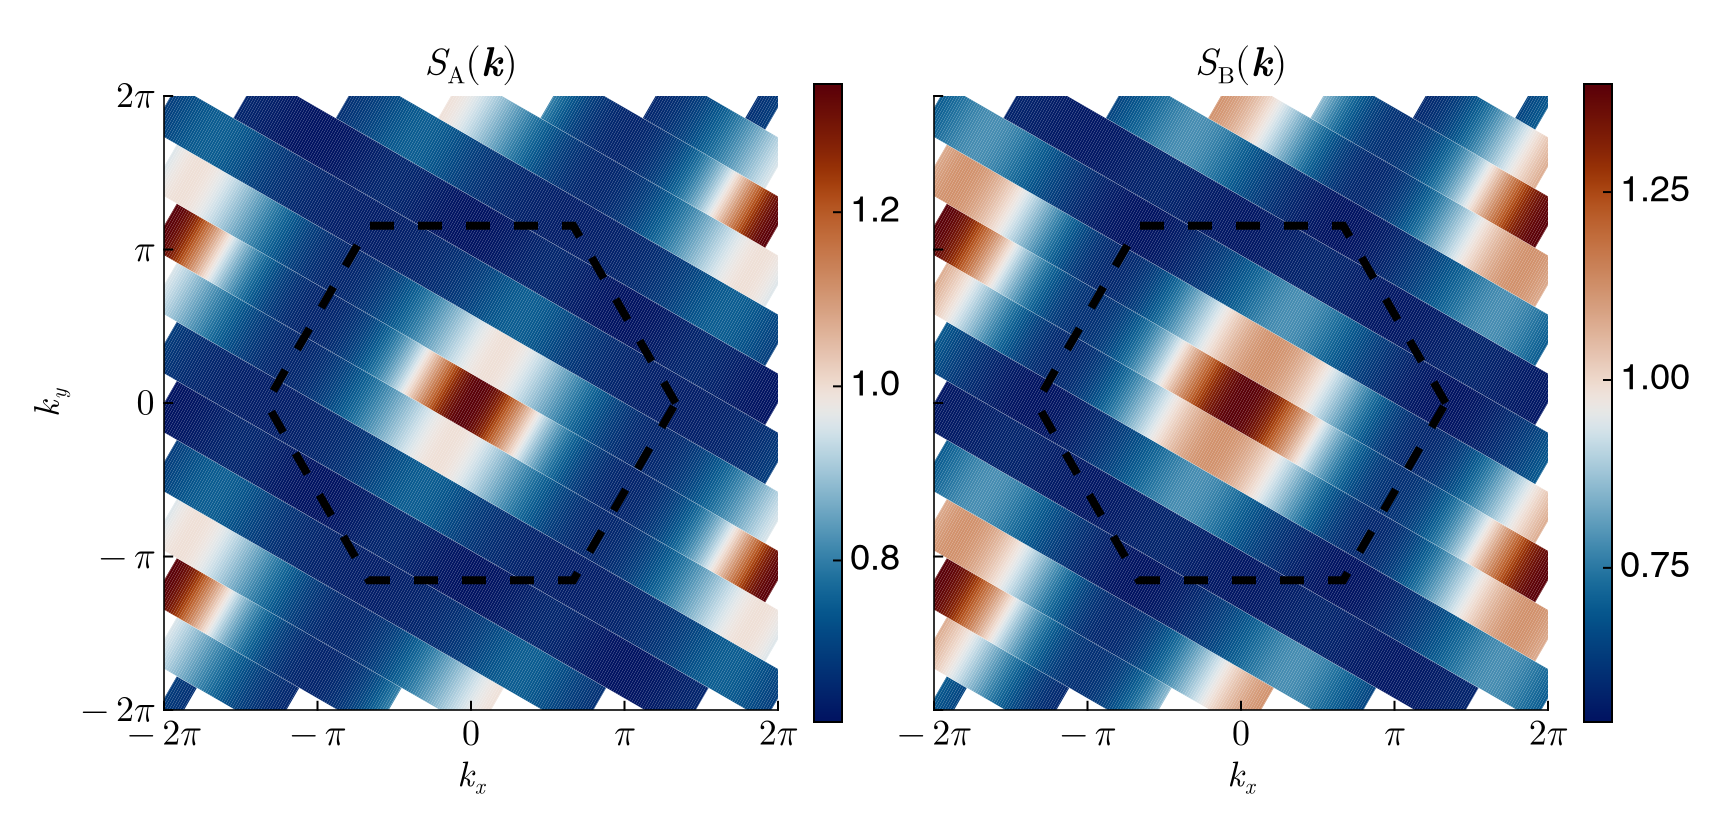

In [39]:

# Spin structure factor plotted only on the valid cylinder momentum cuts.
# For a width-Ny cylinder, the transverse momenta are quantized:
#   k = k1 * b1 + (m/Ny) * b2,  m = -(Ny÷2)+1 … Ny÷2,  k1 ∈ ℝ (continuous)

function plot_sf_cylinder_cuts(cm, Ny; npts=600, colormap=:vik)
    # Reciprocal lattice vectors for honeycomb (a1=[1,0], a2=[0.5, sqrt(3)/2])
    b1 = [2π, -2π / sqrt(3.0)]
    b2 = [0.0,  4π / sqrt(3.0)]

    # Extend m to ±2*Ny to include periodic BZ images that fill the hexagon corners.
    # S(k + n*b2) = S(k) by periodicity, so the extra strips carry the same physics.
    ms      = (-2*Ny):(2*Ny)
    k1_vals = range(-2, 2, length=npts)  # extend beyond BZ so strips don't end abruptly

    # Stripe half-width in BZ coordinates (b2 direction) — controls rendered thickness
    stripe_half = norm(b2) / Ny / 2.3   # half the spacing between cuts

    # Collect (kx, ky, SA, SB) for all valid cuts
    kxs, kys, SqA, SqB, cids = Float64[], Float64[], Float64[], Float64[], Int[]
    for (ci, m) in enumerate(ms)
        for k1 in k1_vals
            kv  = k1 .* b1 .+ (m / Ny) .* b2
            Sk  = structure_factor_2d(cm, Ny, kv[1], kv[2])
            push!(kxs, kv[1]);  push!(kys, kv[2])
            push!(SqA, Sk[1]);  push!(SqB, Sk[2])
            push!(cids, ci)
        end
    end

    # Colorbar limits from the actual data range
    crange_A = (minimum(SqA), maximum(SqA))
    crange_B = (minimum(SqB), maximum(SqB))

    # BZ hexagon
    hex_angles = (0:6) .* (π / 3)
    hex_x = (4π / 3) .* cos.(hex_angles)
    hex_y = (4π / 3) .* sin.(hex_angles)

    # Stripe width in screen points: map data half-width to points
    # We'll use a thick linewidth; adjust via the npts density
    # The spacing between adjacent cuts is |b2|/Ny ≈ 2.42/Ny
    # linewidth is in pt; axis range ≈ 5 rad, figure width ≈ 390pt per panel
    bz_width   = norm(b2)           # ≈ 2π*2/sqrt(3)
    panel_pts  = 390.0              # approx panel width in points
    pts_per_rad = panel_pts / (2 * bz_width)
    lw = max(6.0, 2 * stripe_half * pts_per_rad * 0.9)

    # ── Figure ─────────────────────────────────────────────────────────────────
    fig = Figure(size = (860, 420), fonts = (; regular = "Helvetica"))

    for (col, (Sq, crange, sub)) in enumerate([(SqA, crange_A, "A"), (SqB, crange_B, "B")])
        ax = Axis(fig[1, 2col-1],
            xlabel         = L"k_x",
            ylabel         = col == 1 ? L"k_y" : "",
            title          = L"S_\mathrm{%$(sub)}(\mathbf{k})",
            titlesize      = 20,
            xlabelsize     = 18,
            ylabelsize     = 18,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xtickalign     = 1,
            ytickalign     = 1,
            xticksize      = 5,
            yticksize      = 5,
            spinewidth     = 0.8,
            topspinevisible  = false,
            rightspinevisible = false,
            xgridvisible   = false,
            ygridvisible   = false,
            aspect         = DataAspect(),
            limits         = (-2π, 2π, -2π, 2π),
            xticks         = ([-2π, -π, 0, π, 2π], [L"-2\pi", L"-\pi", L"0", L"\pi", L"2\pi"]),
            yticks         = ([-2π, -π, 0, π, 2π], [L"-2\pi", L"-\pi", L"0", L"\pi", L"2\pi"]),
        )
        if col > 1
            hideydecorations!(ax, grid=false, minorticks=false, ticks=false)
        end

        # Draw each valid momentum strip
        for (ci, m) in enumerate(ms)
            idx = findall(cids .== ci)
            lines!(ax, kxs[idx], kys[idx];
                color      = Sq[idx],
                colormap   = colormap,
                colorrange = crange,
                linewidth  = lw)
        end

        # BZ boundary
        lines!(ax, hex_x, hex_y; color = :black, linewidth = 4, linestyle = :dash)

        Colorbar(fig[1, 2col];
            colormap      = colormap,
            limits        = crange,
            labelsize     = 18,
            ticklabelsize = 18,
            width         = 14,
            tickalign     = 1)
    end

    return fig
end


fig = plot_sf_cylinder_cuts(cm, Ny)

In [40]:
save("figs/SSF_D6400.pdf", fig)

CairoMakie.Screen{PDF}


# Chirality and bond correlations

In [24]:
@show BBcorr = Any[0.11538927483467197, 0.10216387620956534, 0.11333944232274652, 0.1072450531995394, 0.1070093618877771, 0.10948935162769817, 0.10797680998399986, 0.10795475954852328, 0.10855487799708201, 0.10819290651709695, 0.10818599630382085, 0.10832888831996267, 0.10824330308757735, 0.10824148218217154, 0.10827538205192118, 0.10825512252890464, 0.10825466182787111, 0.10826270733113387, 0.10825791016223722, 0.10825779373470597, 0.10825970332225054, 0.10825856746164987, 0.10825853813528463, 0.10825899136666273, 0.10825872242397244, 0.10825871506303608, 0.1082588226345467, 0.10825875895614451, 0.10825875711425618, 0.10825878264552273, 0.1082587675682758, 0.10825876710865645, 0.10825877316827799, 0.10825876959843596, 0.10825876948403453, 0.10825877092222197, 0.10825877007699948, 0.10825877004858914, 0.10825877038993063, 0.10825877018981056, 0.10825877018277384, 0.10825877026378665, 0.108258770216407, 0.10825877021467001, 0.10825877023389888, 0.10825877022268533, 0.1082587702222581, 0.10825877022682454, 0.10825877022417323, 0.10825877022406964] .+ Any[0.08499549858097827, 0.10151381970010392, 0.1133289053358513, 0.10611968486623079, 0.10728364442433048, 0.1092615590363872, 0.10754779945586589, 0.10786318003228249, 0.10832939464998116, 0.10791859243995582, 0.10799343376157246, 0.10810474190244743, 0.10800732627484019, 0.10802488590126517, 0.10805134000658782, 0.10802826264569199, 0.10803239575259602, 0.1080386805388342, 0.10803321213005582, 0.10803418514275304, 0.10803567838663797, 0.10803438257478894, 0.10803461161131991, 0.10803496640036994, 0.10803465934383423, 0.10803471325321426, 0.10803479754879576, 0.10803472478880823, 0.10803473747700716, 0.10803475750491541, 0.1080347402638187, 0.10803474324996311, 0.10803474800838063, 0.10803474392297635, 0.10803474462572145, 0.10803474575626636, 0.1080347447882018, 0.10803474495357299, 0.10803474522217676, 0.10803474499278852, 0.10803474503170689, 0.10803474509552304, 0.10803474504117623, 0.10803474505033325, 0.10803474506549764, 0.10803474505262058, 0.10803474505477731, 0.10803474505838345, 0.1080347450553354, 0.10803474505584412] .- Any[0.09413418240777886, 0.11628797790725923, 0.10577631445319273, 0.1064828170090263, 0.11012502621550291, 0.10750559513754149, 0.10776828511007996, 0.10863076556857335, 0.10799382903444261, 0.10805514206456714, 0.10826168289859359, 0.10811076295533763, 0.1081248908310797, 0.10817394020277181, 0.10813821192506796, 0.10814151245986713, 0.10815315775631044, 0.10814469429960774, 0.10814546540572666, 0.10814823077115777, 0.10814622590443614, 0.1081464059599234, 0.1081470626386445, 0.10814658772422978, 0.10814662975740715, 0.10814678569415788, 0.10814667319665079, 0.10814668300675845, 0.10814672003567952, 0.10814669338745436, 0.10814669567644399, 0.1081467044693173, 0.10814669815696722, 0.1081466986909203, 0.10814670077885881, 0.10814669928361613, 0.10814669940814436, 0.1081466999039343, 0.10814669954975137, 0.10814669957878859, 0.10814669969651924, 0.1081466996126216, 0.10814669961939503, 0.1081466996473519, 0.10814669962748352, 0.10814669962906193, 0.10814669963570482, 0.10814669963100072, 0.10814669963137094, 0.10814669963295072] .- Any[0.1591439678037541, 0.10687669522114081, 0.10504375225434583, 0.11136802421397576, 0.10720391756420805, 0.1075081348027272, 0.10891843937614132, 0.10791080909935746, 0.10799456864065045, 0.10833135735190083, 0.1080910373706685, 0.10811033092402941, 0.10819047594320033, 0.10813357315666144, 0.10813804810450212, 0.10815707568261242, 0.10814359915999439, 0.10814464165690095, 0.10814915952124192, 0.10814596731223625, 0.10814621004577556, 0.10814728280501293, 0.10814652666988246, 0.10814658316271886, 0.10814683788528022, 0.10814665878191453, 0.10814667192525274, 0.10814673240768251, 0.10814668998423857, 0.10814669304099069, 0.10814670740211267, 0.10814669735350411, 0.10814669806414949, 0.10814670147407114, 0.10814669909392484, 0.1081466992590767, 0.10814670006872898, 0.108146699504967, 0.10814669954333156, 0.10814669973557545, 0.10814669960204579, 0.10814669961095535, 0.1081466996566031, 0.10814669962497771, 0.1081466996270498, 0.10814669963788917, 0.10814669963040048, 0.10814669963088325, 0.10814669963345994, 0.10814669963168767]


BBcorr = ((Any[0.11538927483467197, 0.10216387620956534, 0.11333944232274652, 0.1072450531995394, 0.1070093618877771, 0.10948935162769817, 0.10797680998399986, 0.10795475954852328, 0.10855487799708201, 0.10819290651709695, 0.10818599630382085, 0.10832888831996267, 0.10824330308757735, 0.10824148218217154, 0.10827538205192118, 0.10825512252890464, 0.10825466182787111, 0.10826270733113387, 0.10825791016223722, 0.10825779373470597, 0.10825970332225054, 0.10825856746164987, 0.10825853813528463, 0.10825899136666273, 0.10825872242397244, 0.10825871506303608, 0.1082588226345467, 0.10825875895614451, 0.10825875711425618, 0.10825878264552273, 0.1082587675682758, 0.10825876710865645, 0.10825877316827799, 0.10825876959843596, 0.10825876948403453, 0.10825877092222197, 0.10825877007699948, 0.10825877004858914, 0.10825877038993063, 0.10825877018981056, 0.10825877018277384, 0.10825877026378665, 0.108258770216407, 0.10825877021467001, 0.10825877023389888, 0.10825877022268533, 0.1082587702222581, 0.108

50-element Vector{Float64}:
 -0.0528933767958827
 -0.01948697721873076
  0.01584828095105928
 -0.004486103157231872
 -0.003035937467603389
  0.00373718072381668
 -0.0011621150463555496
 -0.0007236350871250574
  0.0008958749719701065
 -0.0002750004594151839
 -0.00017329020386877558
  0.0002125363430430377
 -6.473741186249771e-5
  ⋮
  1.1651902448450713e-7
  1.1586823506215538e-7
  1.1591591569937165e-7
  1.161357327250645e-7
  1.159815850859669e-7
  1.1599267366046995e-7
  1.1604486317706719e-7
  1.1600835481129224e-7
  1.1601093011237573e-7
  1.160233240177222e-7
  1.1601467775346208e-7
  1.1601527535876066e-7

In [6]:
BBcorr_connected = Any[0.007130504610201552, -0.006094894014905081, 0.005080672098276104, -0.001013717024931013, -0.0012494083366933195, 0.0012305814032277512, -0.0002819602404705579, -0.00030401067594713893, 0.0002961077726115896, -6.58637073734647e-5, -7.277392064956867e-5, 7.011809549224701e-5, -1.5467136893071443e-5, -1.7288042298876927e-5, 1.6611827450760397e-5, -3.6476955657810395e-6, -4.1083965993116145e-6, 3.937106663451373e-6, -8.600622331961238e-7, -9.764897644509718e-7, 9.330977801258467e-7, -2.027628205475418e-7, -2.320891857865437e-7, 2.211421923081769e-7, -4.7800497976480116e-8, -5.516143433692555e-8, 5.241007627887484e-8, -1.1268325911251154e-8, -1.3110214233669204e-8, 1.2421052311695213e-8, -2.6561946253611524e-9, -3.115813967946579e-9, 2.9438075727084012e-9, -6.260344603825629e-10, -7.40435893153979e-10, 6.97751550982062e-10, -1.4747093823874735e-10, -1.7588128176093676e-10, 1.6546021497365615e-10, -3.465985831674345e-11, -4.1696576746907965e-11, 3.9316230826536014e-11, -8.063424927762242e-12, -9.800410483151722e-12, 9.42845801432668e-12, -1.7850859679313658e-12, -2.212313665594934e-12, 2.354116901415182e-12, -2.971928259043466e-13, -4.007766341018737e-13]

CCcorr_connected = Any[-0.0008782334338058806, -0.0005281702613912483, -0.00018517391982238518, -4.2362087950753416e-5, -1.0903244054375537e-5, -3.611559628653742e-6, -7.933553860864749e-7, -2.1489648981958026e-7, -8.345927356947232e-8, -1.54549567904838e-8, -3.852016263997723e-9, -1.8512308508049178e-9, -2.0704972902870355e-10, -3.877508378407904e-11, -4.09385884063958e-11, -8.760971968961503e-13, 2.06066400110716e-13, -1.1256161150654118e-12, 5.687573040624987e-14, 2.997988462832471e-14, -3.596067082033314e-14, 3.4504063126436396e-15, 1.4901330833045301e-15, -1.2245388867488196e-15, 1.5200072367836386e-16, 6.247487462882517e-17, -4.3263312856046824e-17, 6.023118145784172e-18, 2.424965440926008e-18, -1.5685225422131126e-18, 2.338990622354671e-19, 8.895988527670345e-20, -5.838390912132872e-20, 1.0427535729038061e-20, 2.6483287483297436e-21, -2.404013999465411e-21, 8.077698271576718e-22, -6.31556063423026e-23, -1.510338561838875e-22, 1.3045435735566516e-22, -4.0698259527023647e-23, -2.050629533305329e-23, 2.868388124596305e-23, -1.0596393422606723e-23, -4.3365955174515696e-24, 6.69750339194069e-24, -2.5707726806988892e-24, -1.0721603428450545e-24, 1.5014167695719606e-24, -6.580914121624813e-25];

flux_colors = (
    energy = :midnightblue,
    sz0    = :midnightblue,
    sz1    = :crimson,
    col_data = RGBf(0.220, 0.490, 0.720),
    col_fit  = RGBf(0.85,  0.20,  0.20),
    guide  = RGBAf(0, 0, 0, 0.25),
)


(energy = :midnightblue, sz0 = :midnightblue, sz1 = :crimson, col_data = RGB{Float32}(0.22, 0.49, 0.72), col_fit = RGB{Float32}(0.85, 0.2, 0.2), guide = RGBA{Float32}(0.0, 0.0, 0.0, 0.25))

In [8]:
CCcorr = Any[-0.0008782334338058776, -0.0005281702613912452, -0.0001851739198223821, -4.236208795075033e-5, -1.0903244054372454e-5, -3.6115596286506597e-6, -7.933553860833925e-7, -2.1489648981649785e-7, -8.345927356638992e-8, -1.5454956787401395e-8, -3.852016260915316e-9, -1.8512308477225113e-9, -2.0704972594629714e-10, -3.877508070167264e-11, -4.09385853239894e-11, -8.760941144897445e-13, 2.0606948251712183e-13, -1.125613032659006e-12, 5.68788128126557e-14, 2.9982967034730533e-14, -3.595758841392732e-14, 3.4534887190494635e-15, 1.4932154897103542e-15, -1.2214564803429955e-15, 1.5508313008418788e-16, 6.55572810346492e-17, -4.01809064502228e-17, 9.105524551608198e-18, 5.507371846750034e-18, 1.5138838636109132e-18, 3.316305468059493e-18, 3.1713662911007292e-18, 3.024022496702697e-18, 3.092833941553064e-18, 3.0850547345723555e-18, 3.0800023918245604e-18, 3.0832141756511834e-18, 3.0823432502176835e-18, 3.082255371967842e-18, 3.0825368601813814e-18, 3.0823657075644987e-18, 3.0823858995286927e-18, 3.0824350897052717e-18, 3.082395809430603e-18, 3.0824020692285083e-18, 3.0824131033274177e-18, 3.082403835051345e-18, 3.082405333663683e-18, 3.0824079072407953e-18, 3.0824057477326136e-18]


50-element Vector{Any}:
 -0.0008782334338058776
 -0.0005281702613912452
 -0.0001851739198223821
 -4.236208795075033e-5
 -1.0903244054372454e-5
 -3.6115596286506597e-6
 -7.933553860833925e-7
 -2.1489648981649785e-7
 -8.345927356638992e-8
 -1.5454956787401395e-8
 -3.852016260915316e-9
 -1.8512308477225113e-9
 -2.0704972594629714e-10
  ⋮
  3.082255371967842e-18
  3.0825368601813814e-18
  3.0823657075644987e-18
  3.0823858995286927e-18
  3.0824350897052717e-18
  3.082395809430603e-18
  3.0824020692285083e-18
  3.0824131033274177e-18
  3.082403835051345e-18
  3.082405333663683e-18
  3.0824079072407953e-18
  3.0824057477326136e-18

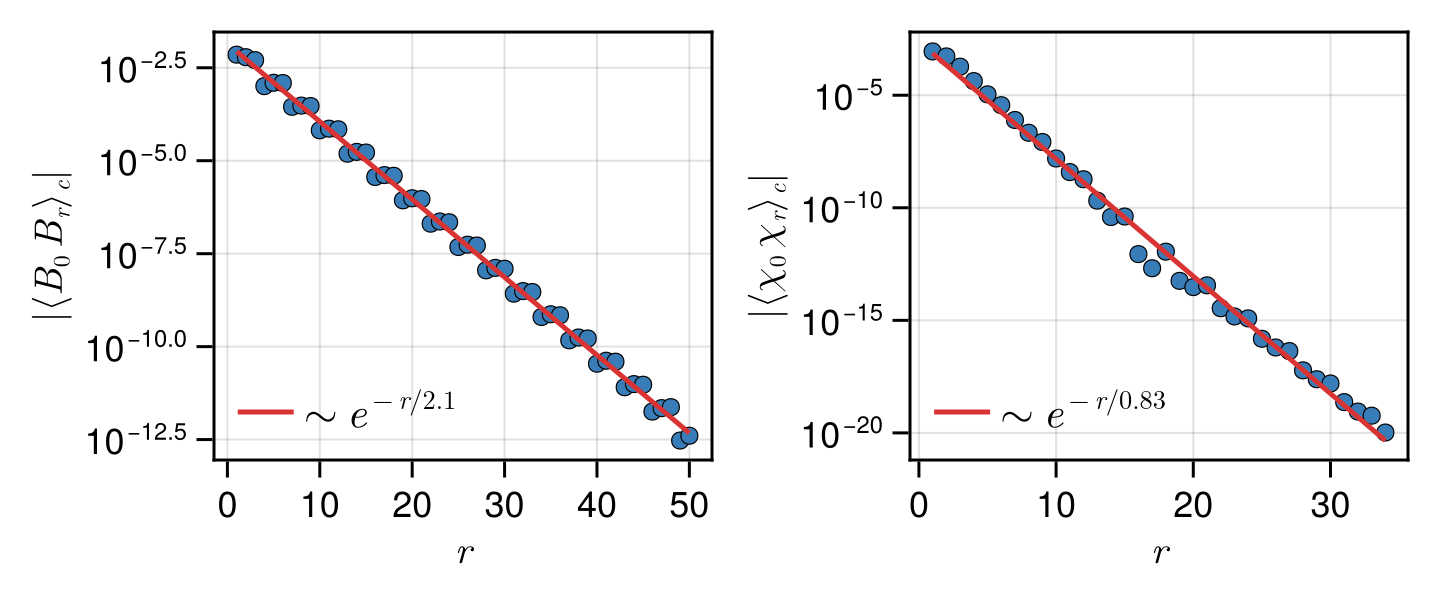

CairoMakie.Screen{IMAGE}


In [28]:

# Bond-bond & Chirality-chirality correlations
# Panel (a): |<B_0 B_r>| vs r,  Panel (b): |<χ_0 χ_r>| vs r  (log scale, exp fit)

# Exponential decay fit: log|C| = a + b·r  →  ξ = -1/b
function fit_corr_length(r_arr, corr_arr; noise_floor=1e-25)
    mask = abs.(Float64.(corr_arr)) .> noise_floor
    rv   = Float64.(r_arr[mask])
    lc   = log.(abs.(Float64.(corr_arr[mask])))
    cf   = [ones(length(rv)) rv] \ lc
    return cf[1], cf[2], -1/cf[2]   # intercept, slope, ξ
end

c_blue  = RGBf(0.220, 0.490, 0.720)
c_green = RGBf(0.200, 0.600, 0.300)
c_black = RGBf(0.10,  0.10,  0.10)

# fig = Figure(size = (560, 500))#, figure_padding = (20, 30, 20, 15))
fig = Figure(size = (720, 300))

fs = 20   # base font size (≥18 pt everywhere)

# ── Panel (a): Bond-bond correlations ────────────────────────
ax1 = Axis(fig[1, 1];
    xlabel = L"r",
    ylabel = L"|\langle B_0\, B_r \rangle_c|",
    yscale = log10,
    xticks = 0:10:50,
    xlabelsize        = fs,
    ylabelsize        = fs,
    xticklabelsize    = fs - 2,
    yticklabelsize    = fs - 2,
    titlesize         = fs,
    xticksize         = 8,
    yticksize         = 8,
    xtickwidth        = 1.5,
    ytickwidth        = 1.5,
    spinewidth        = 1.5,
    xgridvisible      = true,
    ygridvisible      = true,
    xgridcolor        = RGBAf(0,0,0,0.12),
    ygridcolor        = RGBAf(0,0,0,0.12),
)

r_BB = 1:length(BBcorr_connected)
BB   = Float64.(BBcorr_connected)

scatter!(ax1, r_BB, abs.(BB);
    markersize = 12,
    strokecolor = :black,
    strokewidth = 0.6,
         marker = :circle, color = flux_colors.col_data, )
        #  label = latexstring("\\langle B_0 B_r \\rangle"))

a_BB, b_BB, ξ_BB = fit_corr_length(r_BB, BB)
r_fit = range(1.0, Float64(length(BB)), length=300)
lines!(ax1, r_fit, exp.(a_BB .+ b_BB .* r_fit);
       color = flux_colors.col_fit, linewidth = 2.5, linestyle = :solid,
       label = latexstring("\\sim e^{-r/$(round(ξ_BB, digits=1))}"))

axislegend(ax1; position = :lb, labelsize = fs + 2, framevisible = false,
           patchsize = (28, 16))
# Label(fig[1, 1, TopLeft()], "(a)"; fontsize = fs + 2, padding = (0, 0, 0, 0))

# ── Panel (b): Chirality-chirality correlations ───────────────
ax2 = Axis(fig[1, 2];
    xlabel = L"r",
    ylabel = L"|\langle \chi_0\, \chi_r \rangle_c|",
    yscale = log10,
    xticks = 0:10:50,
    xlabelsize        = fs,
    ylabelsize        = fs,
    xticklabelsize    = fs - 2,
    yticklabelsize    = fs - 2,
    titlesize         = fs,
    xticksize         = 8,
    yticksize         = 8,
    xtickwidth        = 1.5,
    ytickwidth        = 1.5,
    spinewidth        = 1.5,
    xgridvisible      = true,
    ygridvisible      = true,
    xgridcolor        = RGBAf(0,0,0,0.12),
    ygridcolor        = RGBAf(0,0,0,0.12),
)

r_CC  = 1:length(CCcorr_connected)
CC    = Float64.(CCcorr_connected)
valid = abs.(CC) .> 1e-20

scatter!(ax2, r_CC[valid], abs.(CC[valid]);
    markersize = 12,
    strokecolor = :black,
    strokewidth = 0.6,
         marker = :circle, color = flux_colors.col_data, )
        #  label = latexstring("\\langle \\chi_0 \\chi_r \\rangle"))

a_CC, b_CC, ξ_CC = fit_corr_length(r_CC[valid], CC[valid])
r_fit_CC = range(Float64(first(r_CC[valid])), Float64(last(r_CC[valid])), length=300)
lines!(ax2, r_fit_CC, exp.(a_CC .+ b_CC .* r_fit_CC);
       color = flux_colors.col_fit, linewidth = 2.5, linestyle = :solid,
       label = latexstring("\\sim e^{-r/$(round(ξ_CC, digits=2))}"))

axislegend(ax2; position = :lb, labelsize = fs + 2, framevisible = false,
           patchsize = (28, 16))
# Label(fig[1, 2, TopLeft()], "(b)"; fontsize = fs + 2, padding = (0, 0, 0, 0))

# colgap!(fig.layout, 40)

display(fig)



In [11]:
save("figs/MPS_correlations2.png", fig)

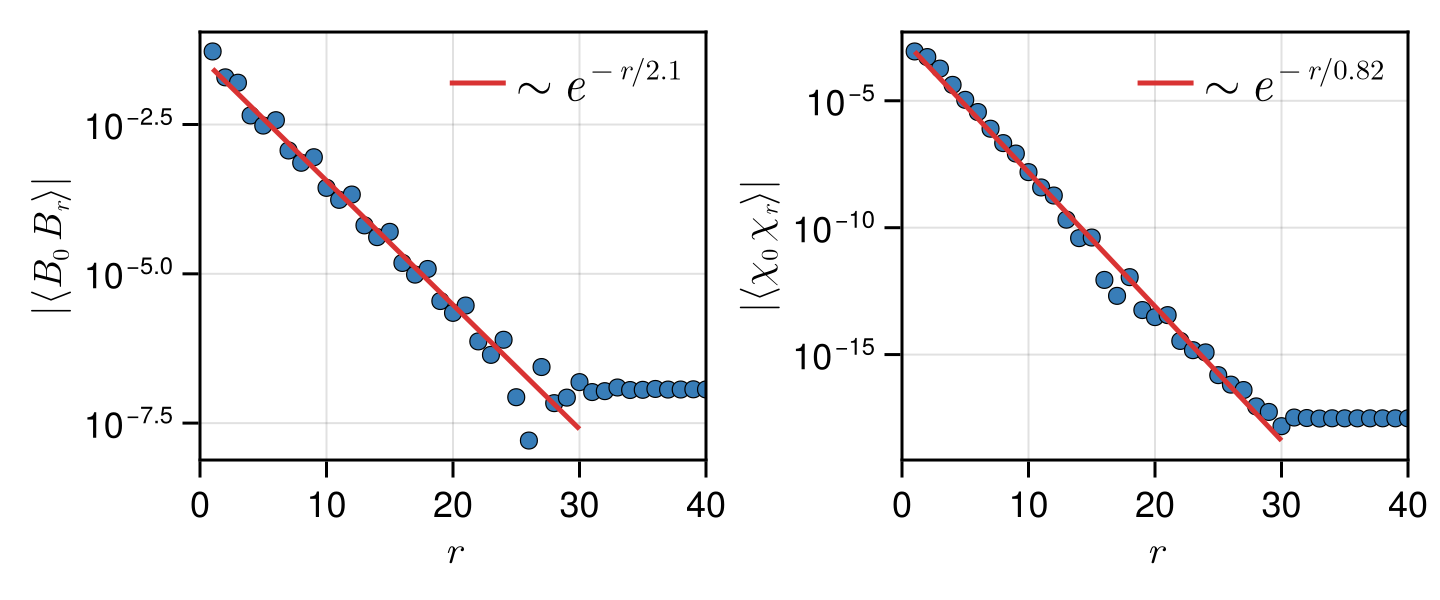

CairoMakie.Screen{IMAGE}


In [32]:
# Unconnected bond-bond and chirality-chirality correlations
# Show the long-distance plateau through r = 40, but fit only the decaying part.
r_plot_max = 40
r_fit_max  = 30
fs = 20

fig_unconnected = Figure(size = (720, 300))

# ── Panel (a): Bond-bond correlations ───────────────────────
ax1_raw = Axis(fig_unconnected[1, 1];
    xlabel = L"r",
    ylabel = L"|\langle B_0\, B_r \rangle|",
    yscale = log10,
    limits = (0, r_plot_max, nothing, nothing),
    xticks = 0:10:r_plot_max,
    xlabelsize = fs, ylabelsize = fs,
    xticklabelsize = fs - 2, yticklabelsize = fs - 2,
    xticksize = 8, yticksize = 8,
    xtickwidth = 1.5, ytickwidth = 1.5, spinewidth = 1.5,
    xgridvisible = true, ygridvisible = true,
    xgridcolor = RGBAf(0, 0, 0, 0.12),
    ygridcolor = RGBAf(0, 0, 0, 0.12),
)

BB_raw = Float64.(BBcorr)
r_BB_raw = collect(1:min(r_plot_max, length(BB_raw)))
BB_plot = BB_raw[r_BB_raw]
BB_fit_mask = r_BB_raw .<= r_fit_max

scatter!(ax1_raw, r_BB_raw, abs.(BB_plot);
    markersize = 12, marker = :circle,
    color = flux_colors.col_data,
    strokecolor = :black, strokewidth = 0.6)

a_BB_raw, b_BB_raw, ξ_BB_raw = fit_corr_length(
    r_BB_raw[BB_fit_mask], BB_plot[BB_fit_mask])
r_BB_fit = range(first(r_BB_raw[BB_fit_mask]), last(r_BB_raw[BB_fit_mask]), length = 300)
lines!(ax1_raw, r_BB_fit, exp.(a_BB_raw .+ b_BB_raw .* r_BB_fit);
    color = flux_colors.col_fit, linewidth = 2.5,
    label = latexstring("\\sim e^{-r/$(round(ξ_BB_raw, digits=1))}"))
axislegend(ax1_raw; position = :rt, labelsize = fs + 4,
    framevisible = false, patchsize = (28, 16))

# ── Panel (b): Chirality-chirality correlations ──────────────
ax2_raw = Axis(fig_unconnected[1, 2];
    xlabel = L"r",
    ylabel = L"|\langle \chi_0\, \chi_r \rangle|",
    yscale = log10,
    limits = (0, r_plot_max, nothing, nothing),
    xticks = 0:10:r_plot_max,
    xlabelsize = fs, ylabelsize = fs,
    xticklabelsize = fs - 2, yticklabelsize = fs - 2,
    xticksize = 8, yticksize = 8,
    xtickwidth = 1.5, ytickwidth = 1.5, spinewidth = 1.5,
    xgridvisible = true, ygridvisible = true,
    xgridcolor = RGBAf(0, 0, 0, 0.12),
    ygridcolor = RGBAf(0, 0, 0, 0.12),
)

CC_raw = Float64.(CCcorr)
r_CC_raw = collect(1:min(r_plot_max, length(CC_raw)))
CC_plot = CC_raw[r_CC_raw]
CC_fit_mask = r_CC_raw .<= r_fit_max

scatter!(ax2_raw, r_CC_raw, abs.(CC_plot);
    markersize = 12, marker = :circle,
    color = flux_colors.col_data,
    strokecolor = :black, strokewidth = 0.6)

a_CC_raw, b_CC_raw, ξ_CC_raw = fit_corr_length(
    r_CC_raw[CC_fit_mask], CC_plot[CC_fit_mask])
r_CC_fit = range(first(r_CC_raw[CC_fit_mask]), last(r_CC_raw[CC_fit_mask]), length = 300)
lines!(ax2_raw, r_CC_fit, exp.(a_CC_raw .+ b_CC_raw .* r_CC_fit);
    color = flux_colors.col_fit, linewidth = 2.5,
    label = latexstring("\\sim e^{-r/$(round(ξ_CC_raw, digits=2))}"))
axislegend(ax2_raw; position = :rt, labelsize = fs + 4,
    framevisible = false, patchsize = (28, 16))

display(fig_unconnected)

In [33]:
save("figs/MPS_correlations_unconnected.png", fig_unconnected)

# Bond strength plots

In [2]:
Ds = [800, 1200, 1600, 3200, 4800, 6400, 9600]

sts = []
nx, ny = 1, 6
j2 = 0.5

for D in Ds
    @load "JLD2depot/HCInfZCdata_Nx$(nx)_Ny$(ny)_J11.0_J2$(j2)_D$(D).jld2" st2
    push!(sts, st2)
end

In [38]:
vals_collection_D = []
for idx in 1:length(sts)
    Nx = 2
    Ny = 6
    pos = positions(Nx, Ny)
    bonds = NNbonds_inf(Nx, Ny, false)
    vals = [real(correlator(sts[idx], SS1, i, j)) for (i, j) in bonds]
    push!(vals_collection_D, vals)
end

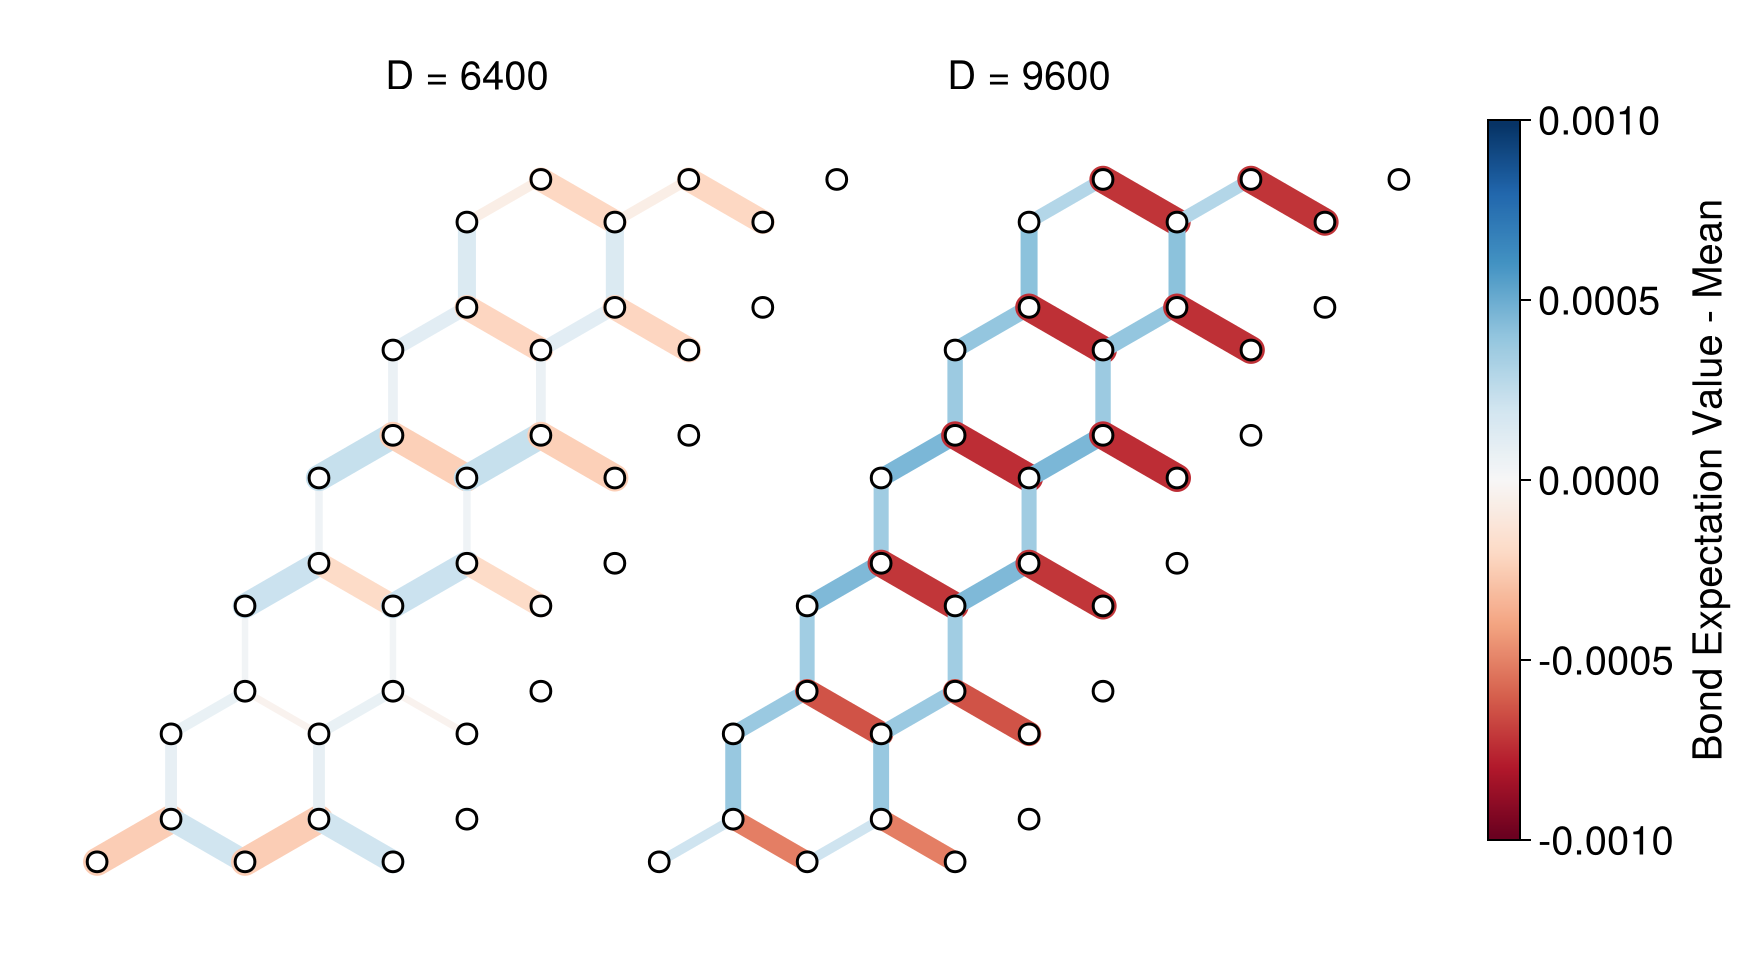

In [104]:
ks = [6, 7]
Nx, Ny = 2, 6
pos = positions(Nx, Ny)
bonds = NNbonds_inf(Nx, Ny, false)

crange = (-1e-3, 1e-3)
lw_min, lw_max = 1.5, 14.0
site_markersize = 14
panel_labels = ["(a)", "(b)", "(c)"]

xs = first.(pos)
ys = last.(pos)
lattice_width = maximum(xs) - minimum(xs)
y_top = maximum(ys)
panel_gap = -1.2

offsets = [0.0, lattice_width + panel_gap]

fig = Figure(size=(880, 480), backgroundcolor=:white, fonts=(; regular="Arial"))
ax = Axis(fig[1, 1], aspect=DataAspect())
hidedecorations!(ax)
hidespines!(ax)

p_bonds = nothing
for (plot_idx, k) in enumerate(ks)
    offset = offsets[plot_idx]
    vals = Float64.(real.(vals_collection_D[k]))
    vals = vals .- sum(vals) / length(vals)

    abs_vals = abs.(vals)
    max_abs = maximum(abs_vals)
    max_abs = max_abs == 0.0 ? 1.0 : max_abs
    linewidths = lw_min .+ (lw_max - lw_min) .* (abs_vals ./ max_abs)

    segments = Point2f[]
    for (i, j) in bonds
        push!(segments, Point2f(pos[i][1] + offset, pos[i][2]))
        push!(segments, Point2f(pos[j][1] + offset, pos[j][2]))
    end

    p_bonds = linesegments!(ax, segments;
        color=repeat(vals, inner=2),
        colormap=:RdBu,
        colorrange=crange,
        linewidth=repeat(linewidths, inner=2),
        linecap=:round)

    # Sites: white fill with black outline for clarity
    scatter!(ax,
        [p[1] + offset for p in pos],
        [p[2] for p in pos];
        color=:white,
        strokecolor=:black,
        strokewidth=1.5,
        markersize=site_markersize)

    # Panel label top-left
    # text!(ax, offset + minimum(xs), y_top + 0.55;
    #     text=panel_labels[plot_idx],
    #     align=(:left, :bottom),
    #     fontsize=16,
    #     font=:bold,
    #     color=:black)

    # Title centred above panel
    text!(ax, offset + (minimum(xs) + maximum(xs)) / 2, y_top + 0.55;
        text="D = $(Ds[k])",
        align=(:center, :bottom),
        fontsize=20,
        color=:black)
end

Colorbar(fig[1, 2], p_bonds;
    label="Bond Expectation Value - Mean",
    labelsize=20,
    ticklabelsize=20,
    tickformat=xs -> [@sprintf("%.4f", x) for x in xs],
    width=16,
    height=360,
    tellheight=false)

colgap!(fig.layout, 12)
fig

In [105]:
save("figs/MPS_bonds.png", fig)

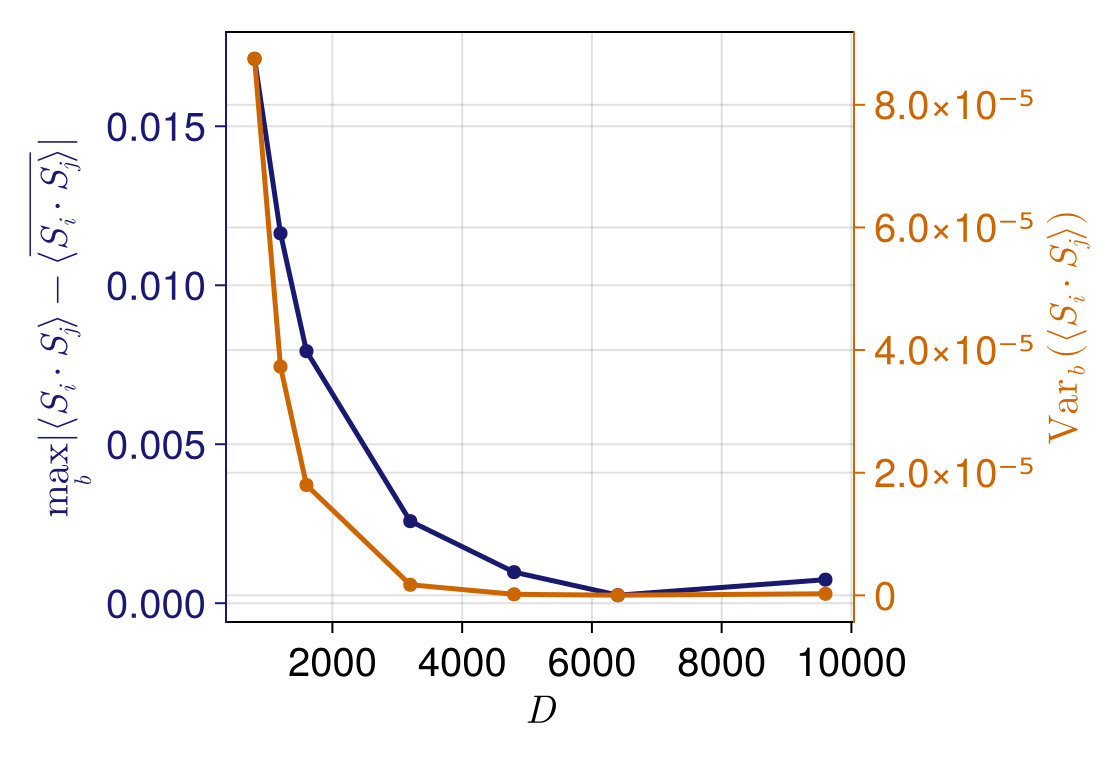

In [ ]:
col1 = :midnightblue
col2 = :darkorange3

fig = Figure(size=(560, 280), backgroundcolor=:white, fonts=(; regular="Arial"))

ax1 = Axis(fig[1, 1];
    xlabel=L"D",
    ylabel=L"\max_b |\langle S_i\cdot S_j\rangle - \overline{\langle S_i\cdot S_j\rangle}|",
    xlabelsize=20,
    ylabelsize=20,
    xticklabelsize=20,
    yticklabelsize=20,
    ylabelcolor=col1,
    yticklabelcolor=col1,
    ytickcolor=col1,
    leftspinecolor=col1,
    yaxisposition=:left)

ax2 = Axis(fig[1, 1];
    ylabel=L"\mathrm{Var}_b\,(\langle S_i\cdot S_j\rangle)",
    ylabelsize=20,
    yticklabelsize=20,
    ylabelcolor=col2,
    yticklabelcolor=col2,
    ytickcolor=col2,
    rightspinecolor=col2,
    yaxisposition=:right)

hidespines!(ax2, :l, :b, :t)
hidexdecorations!(ax2)
linkxaxes!(ax1, ax2)

scatterlines!(ax1, Ds, max_devs_D;
    marker=:circle, markersize=10, linewidth=2.5, color=col1)

scatterlines!(ax2, Ds, bond_vars_D;
    marker=:circle, markersize=10, linewidth=2.5, color=col2)

fig

In [103]:
save("figs/MPS_uniform.png", fig)

# Entanglement fittings

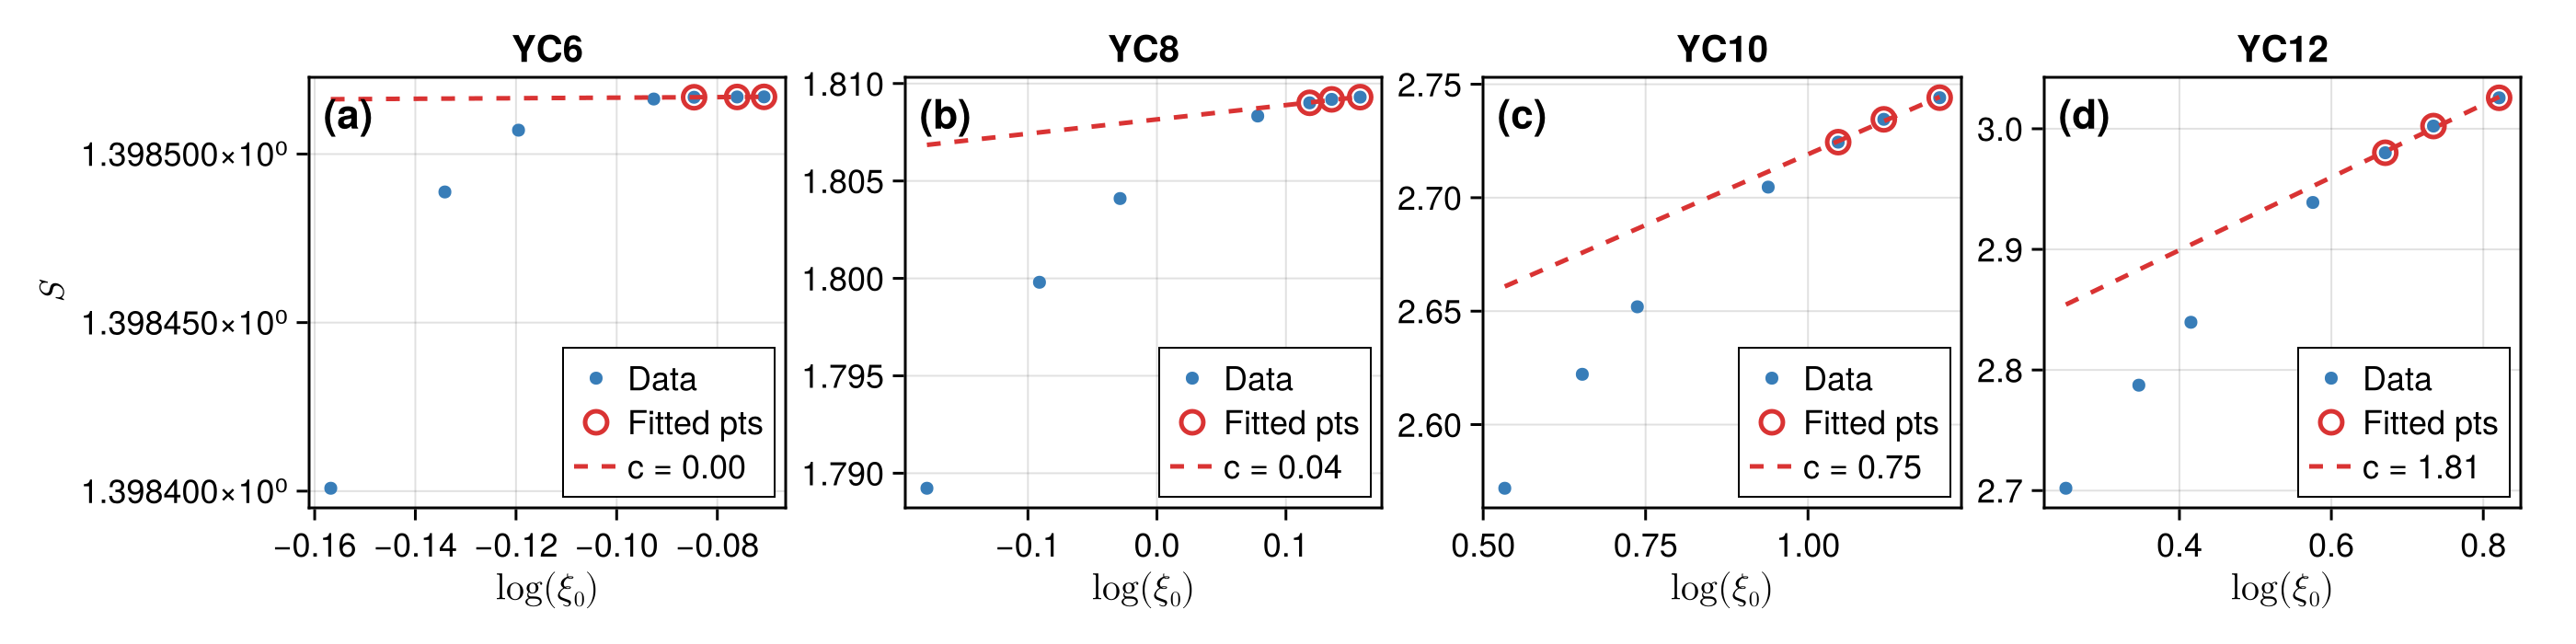

In [2]:
# 4-panel entanglement entropy scaling: YC6, YC8, YC10, YC12
# Cardy formula: S = (c/6) log(ξ₀) + const

# ── Embedded data ─────────────────────────────────────────────────────────────
xi0_6  = [0.8548732232461769, 0.8744776924844037, 0.8873641724194739,
           0.9115337061908515, 0.9188651997046374, 0.9267524559145872, 0.9317178231153996]
Ss_6   = [1.3984008488670154, 1.3984887483859973, 1.3985070829826842,
           1.398516321118149,  1.3985168497235303, 1.3985169327926772, 1.3985169613295607]

xi0_8  = [0.836697022411862,  0.9129649069649272, 0.9718433411981342,
           1.0812825588980735, 1.1257129015997471, 1.1450801015568841, 1.1706392339201506]
Ss_8   = [1.7892279037420662, 1.799800588869115,  1.804097813615043,
           1.8083327815199046, 1.8090107113267884, 1.8091873618731207, 1.8093021593050225]

xi0_10 = [1.7044337849574829, 1.9204713567111775, 2.0903080643073673,
           2.5566869783025603, 2.847537789875244,  3.0546458687781577, 3.329060402645808]
Ss_10  = [2.5719433093726214, 2.6221725254607424, 2.651916588932207,
           2.7046607163155874, 2.7244859198281355, 2.7345371211473157, 2.7440708937724096]

xi0_12 = [1.2847182934547516, 1.4142196808297216, 1.5145729766406832,
           1.7782666207370892, 1.9561992782576276, 2.0842813771631663, 2.2724655328916565]
Ss_12  = [2.701919828823665,  2.7873772845842018, 2.8395448604549025,
           2.9388773967418254, 2.9800976558032763, 3.0022283634389733, 3.0256464488032906]

xi0_all      = [xi0_6,  xi0_8,  xi0_10,  xi0_12]
Ss_all       = [Ss_6,   Ss_8,   Ss_10,   Ss_12]
panel_names  = ["YC6",  "YC8",  "YC10",  "YC12"]
panel_labels = ["(a)", "(b)", "(c)", "(d)"]
panel_pos    = [(1,1), (1,2), (1,3), (1,4)]

# ── Fit: S = (c/6) log(ξ₀) + b on last 3 points ─────────────────────────────
function fit_ee(xi0_arr, S_arr; nfit=3)
    lx = log.(xi0_arr[end-nfit+1:end])
    Sf = S_arr[end-nfit+1:end]
    cf = [lx ones(nfit)] \ Sf
    return cf[1], cf[2], 6*cf[1]   # c/6, intercept, c
end

# ── Style ─────────────────────────────────────────────────────────────────────
fs     = 20
col_data = RGBf(0.220, 0.490, 0.720)
col_fit  = RGBf(0.85,  0.20,  0.20)

fig = Figure(size = (1400, 350), figure_padding = (20, 30, 20, 15))

for idx in 1:4
    name    = panel_names[idx]
    xi0_arr = xi0_all[idx]
    S_arr   = Ss_all[idx]
    plabel  = panel_labels[idx]
    panel_row, panel_col = panel_pos[idx]

    log_xi       = log.(xi0_arr)
    c6, b, cval  = fit_ee(xi0_arr, S_arr)

    ax = Axis(fig[panel_row, panel_col];
        xlabel         = L"\log(\xi_0)",
        ylabel         = idx == 1 ? L"S" : "",
        title          = name,
        xlabelsize     = fs,
        ylabelsize     = fs,
        titlesize      = fs,
        xticklabelsize = fs - 2,
        yticklabelsize = fs - 2,
        xticksize      = 6,
        yticksize      = 6,
        xtickwidth     = 1.5,
        ytickwidth     = 1.5,
        spinewidth     = 1.5,
        xgridvisible   = true,
        ygridvisible   = true,
        xgridcolor     = RGBAf(0, 0, 0, 0.12),
        ygridcolor     = RGBAf(0, 0, 0, 0.12),
    )

    # All data points
    scatter!(ax, log_xi, S_arr;
             marker = :circle, color = col_data, markersize = 10,
             label = "Data")

    # Highlight the 3 fitted points
    scatter!(ax, log_xi[end-2:end], S_arr[end-2:end];
             marker = :circle, markersize = 17,
             color = :transparent, strokecolor = col_fit, strokewidth = 2.5,
             label = "Fitted pts")

    # Fit line across full data range
    x_line = range(minimum(log_xi), maximum(log_xi), length=200)
    lines!(ax, x_line, c6 .* x_line .+ b;
           color = col_fit, linewidth = 2.5, linestyle = :dash,
           label = @sprintf("c = %.2f", cval))

    axislegend(ax; position = :rb, labelsize = fs - 2,
               framevisible = true, patchsize = (24, 14))

    text!(ax, 0.03, 0.97; text = plabel, space = :relative,
          align = (:left, :top), fontsize = fs + 2, font = :bold)
end

rowgap!(fig.layout, 10)
colgap!(fig.layout, 10)

fig


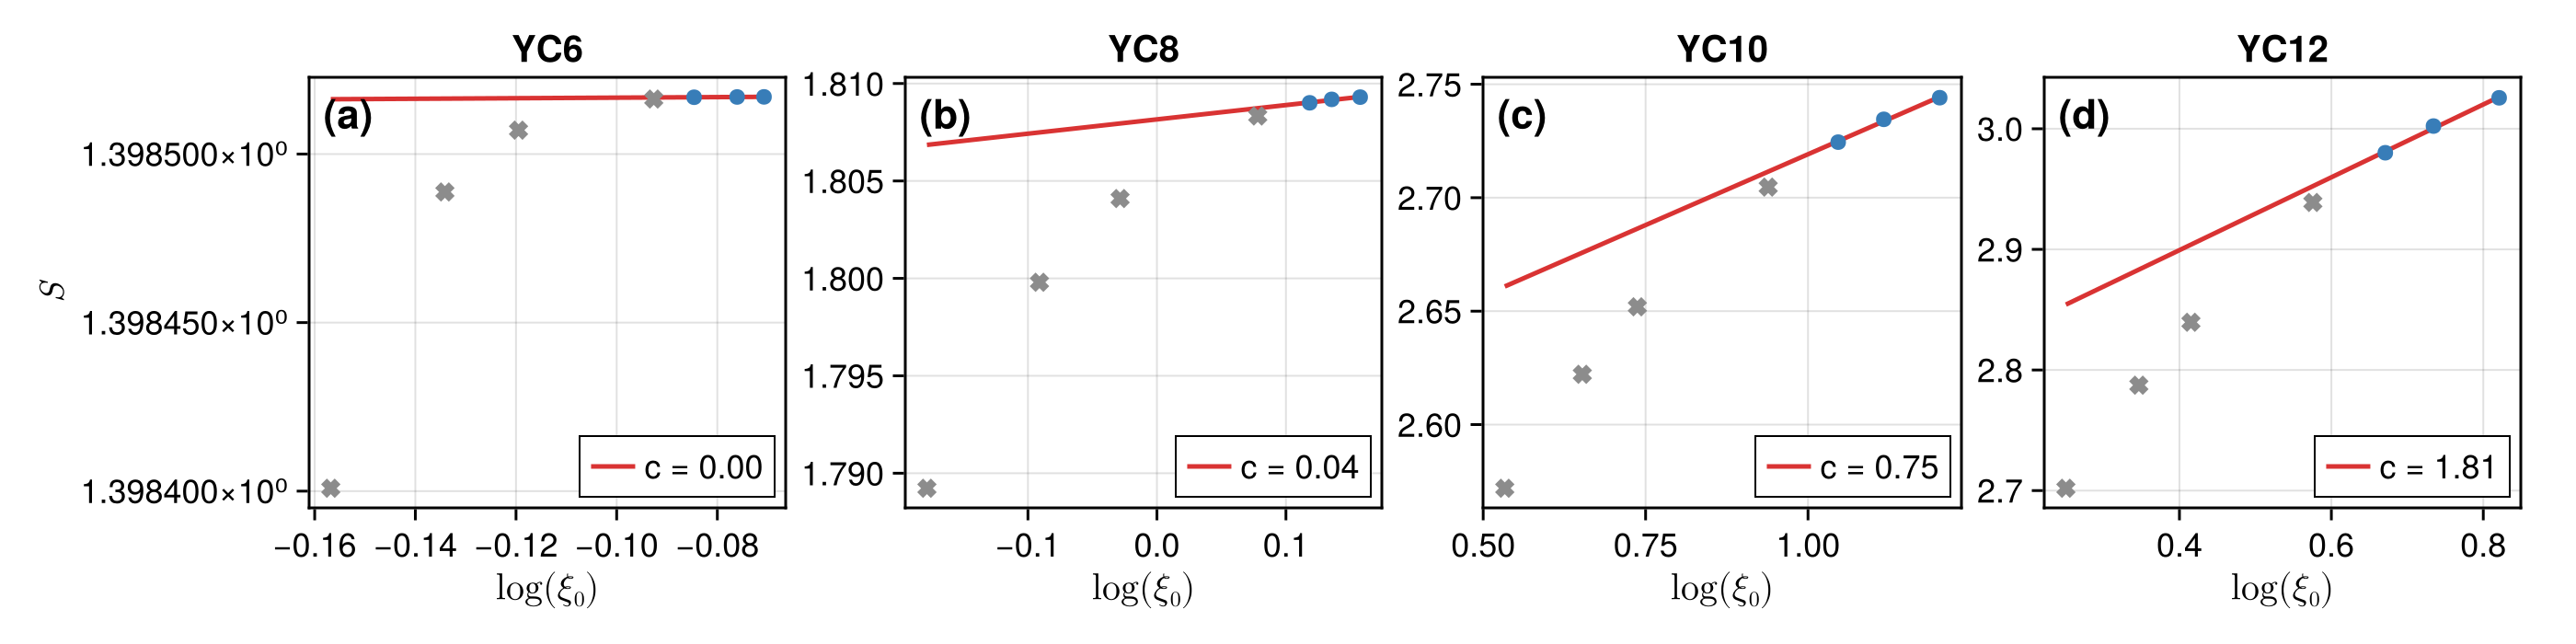

In [3]:
# Alternative: cross out unfitted points instead of ringing fitted ones
# Unfitted points → × marker (no legend); fitted points → solid circle (in legend)

fs     = 20
col_data   = RGBf(0.220, 0.490, 0.720)
col_excl   = RGBf(0.55, 0.55, 0.55)   # muted grey for excluded points
col_fit    = RGBf(0.85, 0.20, 0.20)

fig2 = Figure(size = (1400, 350), figure_padding = (20, 30, 20, 15))

for idx in 1:4
    name    = panel_names[idx]
    xi0_arr = xi0_all[idx]
    S_arr   = Ss_all[idx]
    plabel  = panel_labels[idx]
    panel_row, panel_col = panel_pos[idx]

    log_xi      = log.(xi0_arr)
    c6, b, cval = fit_ee(xi0_arr, S_arr)
    nfit        = 3
    split       = length(log_xi) - nfit   # index boundary

    ax = Axis(fig2[panel_row, panel_col];
        xlabel         = L"\log(\xi_0)",
        ylabel         = idx == 1 ? L"S" : "",
        title          = name,
        xlabelsize     = fs,
        ylabelsize     = fs,
        titlesize      = fs,
        xticklabelsize = fs - 2,
        yticklabelsize = fs - 2,
        xticksize      = 6,
        yticksize      = 6,
        xtickwidth     = 1.5,
        ytickwidth     = 1.5,
        spinewidth     = 1.5,
        xgridvisible   = true,
        ygridvisible   = true,
        xgridcolor     = RGBAf(0, 0, 0, 0.12),
        ygridcolor     = RGBAf(0, 0, 0, 0.12),
    )

    

    # Fit line across full range
    x_line = range(minimum(log_xi), maximum(log_xi), length=200)
    lines!(ax, x_line, c6 .* x_line .+ b;
           color = col_fit, linewidth = 2.5, linestyle = :solid,
           label = @sprintf("c = %.2f", cval))
    
    # Excluded points: × marker, muted color, no legend label
    scatter!(ax, log_xi[1:split], S_arr[1:split];
             marker = :xcross, color = col_excl, markersize = 12,
             strokewidth = 1.5, strokecolor = col_excl)

    # Fitted points: solid circle, data color, appears in legend
    scatter!(ax, log_xi[end-nfit+1:end], S_arr[end-nfit+1:end];
             marker = :circle, color = col_data, markersize = 12)
            #  ,label = "Fitted pts")

    axislegend(ax; position = :rb, labelsize = fs - 2,
               framevisible = true, patchsize = (24, 14))

    text!(ax, 0.03, 0.97; text = plabel, space = :relative,
          align = (:left, :top), fontsize = fs + 2, font = :bold)
end

rowgap!(fig2.layout, 10)
colgap!(fig2.layout, 10)

fig2

In [49]:
save("figs/EE_scaling.pdf", fig2)

CairoMakie.Screen{PDF}


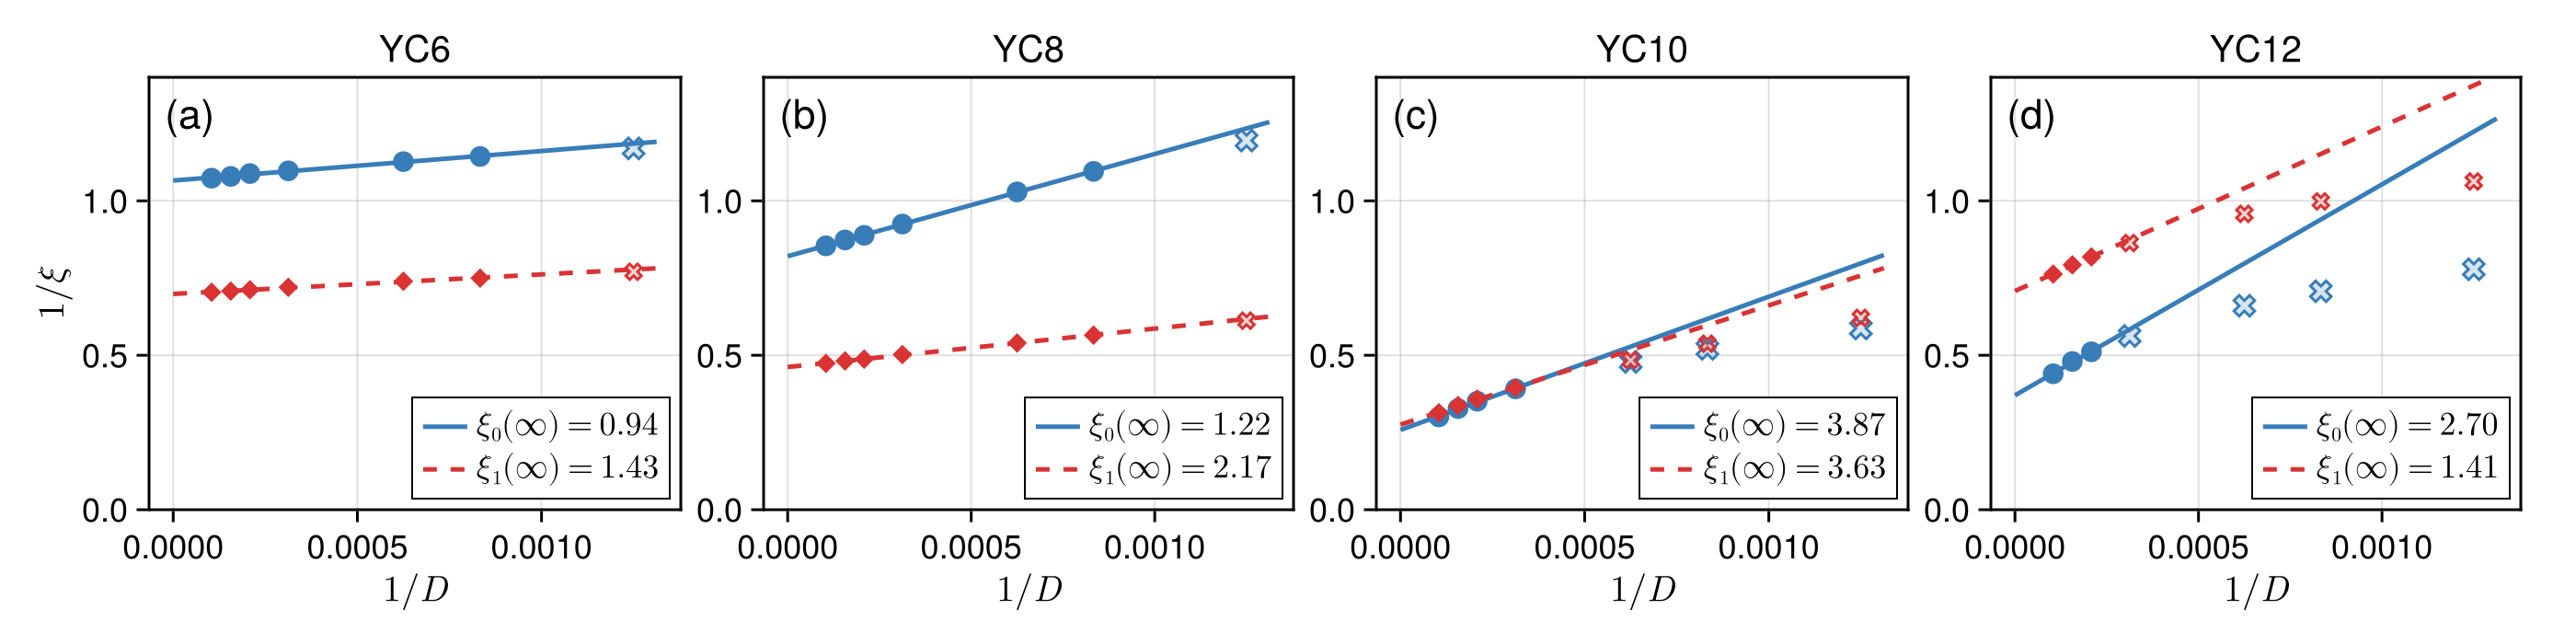

In [4]:
# 4-panel 1/xi0 and 1/xi1 vs 1/D scaling: YC6, YC8, YC10, YC12
# Linear extrapolation to 1/D -> 0 gives xi(D->inf)

Ds_arr = [800, 1200, 1600, 3200, 4800, 6400, 9600]
inv_D  = 1.0 ./ Ds_arr

inv_xi0_6  = 1.0 ./ [0.8548732232461769, 0.8744776924844037, 0.8873641724194739,
                      0.9115337061908515, 0.9188651997046374, 0.9267524559145872, 0.9317178231153996]
inv_xi1_6  = 1.0 ./ [1.298186019592591,  1.3338101126898165, 1.3522660844691134,
                      1.3889276074207568, 1.404581842877886,  1.4130858837036546, 1.420588593395696]

inv_xi0_8  = 1.0 ./ [0.836697022411862,  0.9129649069649272, 0.9718433411981342,
                      1.0812825588980735, 1.1257129015997471, 1.1450801015568841, 1.1706392339201506]
inv_xi1_8  = 1.0 ./ [1.634156248587533,  1.7694162691348705, 1.8531958396423034,
                      1.9912448168267483, 2.051134923927362,  2.076808952869027,  2.1109662272575154]

inv_xi0_10 = 1.0 ./ [1.7044337849574829, 1.9204713567111775, 2.0903080643073673,
                      2.5566869783025603, 2.847537789875244,  3.0546458687781577, 3.329060402645808]
inv_xi1_10 = 1.0 ./ [1.610418011675751,  1.8601945399982018, 2.0672610690190205,
                      2.532635639806274,  2.793534536494981,  2.9662756985430936, 3.1866167216927352]

inv_xi0_12 = 1.0 ./ [1.2847182934547516, 1.4142196808297216, 1.5145729766406832,
                      1.7782666207370892, 1.9561992782576276, 2.0842813771631663, 2.2724655328916565]
inv_xi1_12 = 1.0 ./ [0.9411593465269639, 1.001930967369282,  1.0439177693872066,
                      1.1582931156477252, 1.2220187566331728, 1.26171246989301,   1.3108631146696883]

inv_xi0_all = [inv_xi0_6, inv_xi0_8, inv_xi0_10, inv_xi0_12]
inv_xi1_all = [inv_xi1_6, inv_xi1_8, inv_xi1_10, inv_xi1_12]
panel_names_xi = ["YC6", "YC8", "YC10", "YC12"]
panel_labs_xi  = ["(a)", "(b)", "(c)", "(d)"]

fs         = 20
col_d0     = RGBf(0.220, 0.490, 0.720)   # blue  for xi0
col_f0     = RGBf(0.85,  0.20,  0.20)    # red   fit xi0
col_d1     = RGBf(0.85,  0.20,  0.20) #RGBf(0.133, 0.545, 0.133)   # green for xi1
col_f1     = RGBf(0.90,  0.55,  0.00)    # orange fit xi1
col_excl   = RGBf(0.55,  0.55,  0.55)    # grey excluded
nfit       = [6, 6, 4, 3]   # number of points to fit for each panel

fig_xi = Figure(size = (1400, 350), figure_padding = (20, 30, 20, 15))

for idx in 1:4
    inv_xi0 = inv_xi0_all[idx]
    inv_xi1 = inv_xi1_all[idx]
    plabel  = panel_labs_xi[idx]
    name    = panel_names_xi[idx]
    split_i = length(inv_D) - nfit[idx]

    # Fits on last nfit points
    X  = [inv_D[end-nfit[idx]+1:end] ones(nfit[idx])]
    cf0 = X \ inv_xi0[end-nfit[idx]+1:end]
    cf1 = X \ inv_xi1[end-nfit[idx]+1:end]
    xi0_inf = 1.0 / cf0[2]
    xi1_inf = 1.0 / cf1[2]
    xi0_str = @sprintf("%.2f", xi0_inf)
    xi1_str = @sprintf("%.2f", xi1_inf)

    ax = Axis(fig_xi[1, idx];
        xlabel         = L"1/D",
        ylabel         = idx == 1 ? L"1/\xi" : "",
        title          = name,
        titlefont      = :regular,
        xlabelsize     = fs,
        ylabelsize     = fs,
        titlesize      = fs,
        xticklabelsize = fs - 2,
        yticklabelsize = fs - 2,
        xticksize      = 6,
        yticksize      = 6,
        xtickwidth     = 1.5,
        ytickwidth     = 1.5,
        spinewidth     = 1.5,
        xgridvisible   = true,
        ygridvisible   = true,
        xgridcolor     = RGBAf(0, 0, 0, 0.12),
        ygridcolor     = RGBAf(0, 0, 0, 0.12),
        limits = (nothing, nothing, 0.0, 1.4),
    )

    x_line = range(0, maximum(inv_D) * 1.05, length=200)

    # xi0 fit line + points
    lines!(ax, x_line, cf0[1] .* x_line .+ cf0[2];
           color = col_d0, linewidth = 2.5, linestyle = :solid,
           label = latexstring("\\xi_0(\\infty) = $(xi0_str)"))
    scatter!(ax, inv_D[1:split_i], inv_xi0[1:split_i];
             marker = :xcross, color = col_d0, markersize = 16,
             strokewidth = 1.5, strokecolor = col_d0, alpha = 0.2)
    scatter!(ax, inv_D[end-nfit[idx]+1:end], inv_xi0[end-nfit[idx]+1:end];
             marker = :circle, color = col_d0, markersize = 16)

    # xi1 fit line + points
    lines!(ax, x_line, cf1[1] .* x_line .+ cf1[2];
           color = col_d1, linewidth = 2.5, linestyle = :dash,
           label = latexstring("\\xi_1(\\infty) = $(xi1_str)"))
    scatter!(ax, inv_D[1:split_i], inv_xi1[1:split_i];
             marker = :xcross, color = col_d1, markersize = 12,
             strokewidth = 1.5, strokecolor = col_d1, alpha = 0.2)
    scatter!(ax, inv_D[end-nfit[idx]+1:end], inv_xi1[end-nfit[idx]+1:end];
             marker = :diamond, color = col_d1, markersize = 12)

    axislegend(ax; position = :rb, labelsize = fs - 2,
               framevisible = true, patchsize = (24, 14))

    text!(ax, 0.03, 0.97; text = plabel, space = :relative,
          align = (:left, :top), fontsize = fs + 2)#, font = :bold)
end

rowgap!(fig_xi.layout, 10)
colgap!(fig_xi.layout, 10)

fig_xi

In [5]:
save("figs/xi_scaling.pdf", fig_xi)

CairoMakie.Screen{PDF}


# Strange correlators

In [14]:
# spin operators
function U1spin_operators(flux=0)
    Sx = 1 / 2 * ComplexF64[0 1; 1 0]
    Sy = 1 / 2 * ComplexF64[0 -1im; 1im 0]
    Sz = 1 / 2 * ComplexF64[1 0; 0 -1]

    Sp = Sx + 1im * Sy  # S+ = Sx + i*Sy
    Sm = Sx - 1im * Sy  # S- = Sx - i*Sy
    phasep = exp(1im * 2*π * flux)
    phasem = exp(-1im * 2*π * flux) 

    @tensor Spm_arr[-1 -2; -3 -4] := Sp[-1; -3] * Sm[-2; -4] * phasep # S+_i S-_j
    @tensor Smp_arr[-1 -2; -3 -4] := Sm[-1; -3] * Sp[-2; -4] * phasem # S-_i S+_j
    @tensor Szz_arr[-1 -2; -3 -4] := Sz[-1; -3] * Sz[-2; -4]
    @tensor SS_arr[-1 -2; -3 -4] := 0.5 * Spm_arr[-1 -2; -3 -4] + 0.5 * Smp_arr[-1 -2; -3 -4] + Szz_arr[-1 -2; -3 -4]

    P = Vect[U1Irrep]((-1//2) => 1, (1//2) => 1)
    # Spm = TensorMap(Spm_arr, P ⊗ P, P ⊗ P)
    # Smp = TensorMap(Smp_arr, P ⊗ P, P ⊗ P)
    # Szz = TensorMap(Szz_arr, P ⊗ P, P ⊗ P)
    SS = TensorMap(SS_arr, P ⊗ P, P ⊗ P)

    @tensor Schi_arr[-1 -2 -3; -4 -5 -6] := Sx[-1; -4] * (Sy[-2; -5] * Sz[-3; -6] - Sz[-2; -5] * Sy[-3; -6]) + Sy[-1; -4] * (Sz[-2; -5] * Sx[-3; -6] - Sx[-2; -5] * Sz[-3; -6]) + Sz[-1; -4] * (Sx[-2; -5] * Sy[-3; -6] - Sy[-2; -5] * Sx[-3; -6])
    Schi = TensorMap(Schi_arr, P ⊗ P ⊗ P, P ⊗ P ⊗ P) 

    Szop = TensorMap(Sz, P, P)

    return SS, Schi, Szop
end

function make_ham_inf_stag(J1, J2, Nx, Ny, yperiodic=true)
    # SS2 = S_exchange(ComplexF64, U1Irrep; spin=1 // 2)
    SS0, Schi, Szop = U1spin_operators(0)
    
    N = Nx * Ny * 2
    lat = InfiniteChain(N)
    get_idx(ix, iy, s) = (ix - 1) * (2 * Ny) + (iy - 1) * 2 + 1 + s

    As = []
    Bs = []
    for ix in 1:Nx
        for iy in 1:Ny
            idxA = get_idx(ix, iy, 0)
            idxB = get_idx(ix, iy, 1)
            push!(As, lat[idxA])
            push!(Bs, lat[idxB])
        end
    end

    Hlist = [[LocalOperator(Szop, i) * J1 for i in As]..., 
             [LocalOperator(Szop, i) * (-J1) for i in Bs]...]

    return @mpoham sum(Hlist)
end

make_ham_inf_stag (generic function with 2 methods)

In [23]:
Nx = 1
Ny = 6
D = 200

L = div(Nx*Ny*2, 2) # number of unit cells
PS = Rep[U₁](1 // 2 => 1, -1//2 => 1)
Ps = repeat([PS, PS], L)

Vs =[Rep[U₁](0=>7, 1=>13, 2=>8, 3=>2), Rep[U₁](1/2=>12, 3/2=>12, 5/2=>4), Rep[U₁](0=>8, 1=>14, 2=>8, 3=>1), Rep[U₁](1/2=>13, 3/2=>12, 5/2=>4)]

st0 = InfiniteMPS(Ps, repeat(Vs[1:4], L)[1:2*L])
@show χ0 = [dim(left_virtualspace(st0, si)) for si in 1:length(st0)]

Hst = make_ham_inf_stag(-1.0, 0., Nx, Ny, true)

χ0 = [dim(left_virtualspace(st0, si)) for si = 1:length(st0)] = [29, 30, 28, 31, 29, 30, 28, 31, 29, 30, 28, 31]


12-site InfiniteMPOHamiltonian{BlockTensorKit.SparseBlockTensorMap{AbstractTensorMap{ComplexF64, GradedSpace{U1Irrep, TensorKit.SortedVectorDict{U1Irrep, Int64}}, 2, 2}, ComplexF64, GradedSpace{U1Irrep, TensorKit.SortedVectorDict{U1Irrep, Int64}}, 2, 2, 4}}:
╷  ⋮
┼ W[12]: 2×1×1×2 SparseBlockTensorMap(((Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1)) ⊗ ⊕(Rep[U₁](1/2=>1, -1/2=>1))) ← (⊕(Rep[U₁](1/2=>1, -1/2=>1)) ⊗ (Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1))))
┼ W[11]: 2×1×1×2 SparseBlockTensorMap(((Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1)) ⊗ ⊕(Rep[U₁](1/2=>1, -1/2=>1))) ← (⊕(Rep[U₁](1/2=>1, -1/2=>1)) ⊗ (Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1))))
┼ W[10]: 2×1×1×2 SparseBlockTensorMap(((Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1)) ⊗ ⊕(Rep[U₁](1/2=>1, -1/2=>1))) ← (⊕(Rep[U₁](1/2=>1, -1/2=>1)) ⊗ (Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1))))
┼ W[9]:  2×1×1×2 SparseBlockTensorMap(((Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1)) ⊗ ⊕(Rep[U₁](1/2=>1, -1/2=>1))) ← (⊕(Rep[U₁](1/2=>1, -1/2=>1)) ⊗ (Rep[U₁](0=>1) ⊕ Rep[U₁](0=>1))))
┼ W[8]:  2×1×1×2 SparseBlockTensorMap(((Rep[U₁](0=>1) ⊕ Rep[

In [24]:
expand_steps = 5 # choose number of expansion steps
gs_iter = 15 # choose maximal number of VUMPS iterations to do before each expansion
gs_tol = 1e-5 # choose tolerance for VUMPS before each expansion

temp_gs_alg = VUMPS(; tol=gs_tol, maxiter=gs_iter, verbosity=2) # high tolerance, low maxiter
# expansion algorithm that adds charges and bond dimension as long as the schmidt values are below `schmidtcut`
expand_alg = VUMPSSvdCut(; trscheme=truncdim(D))

ψ = st0

for _ in 1:expand_steps
    global ψ # REPL scope nonsense
    ψ, envs, delta = find_groundstate(ψ, Hst, temp_gs_alg)
    # delta < gs_tol && break
    ψ, envs = changebonds(ψ, Hst, expand_alg, envs)
    @show [dim(left_virtualspace(ψ, i)) for i in 1:length(ψ)]
end

[ Info: VUMPS init:	obj = -7.296727704742e-02	err = 4.1264e-01
[ Info: VUMPS conv 2:	obj = -5.999999999999e+00	err = 1.7979696597e-06	time = 0.42 sec


[dim(left_virtualspace(ψ, i)) for i = 1:length(ψ)] = [112, 56, 62, 58, 60, 56, 62, 58, 60, 56, 62, 58]


[ Info: VUMPS init:	obj = -6.000000000000e+00	err = 4.4282e-07
[ Info: VUMPS conv 1:	obj = -6.000000000000e+00	err = 2.3400277368e-09	time = 0.79 sec
┌ Warning: Constructing an MPS from tensors that are not full rank
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/states/infinitemps.jl:149


[dim(left_virtualspace(ψ, i)) for i = 1:length(ψ)] = [200, 123, 116, 120, 112, 124, 116, 120, 112, 124, 116, 200]


[ Info: VUMPS init:	obj = -6.000000000000e+00	err = 2.0260e-09
[ Info: VUMPS conv 1:	obj = -6.000000000000e+00	err = 1.8871502599e-11	time = 2.76 sec
┌ Warning: Constructing an MPS from tensors that are not full rank
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/states/infinitemps.jl:149
┌ Warning: Constructing an MPS from tensors that are not full rank
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/states/infinitemps.jl:149
┌ Warning: Constructing an MPS from tensors that are not full rank
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/states/infinitemps.jl:149
┌ Warning: Constructing an MPS from tensors that are not full rank
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/states/infinitemps.jl:149


[dim(left_virtualspace(ψ, i)) for i = 1:length(ψ)] = [200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


[ Info: VUMPS init:	obj = -6.000000000000e+00	err = 1.7417e-11
┌ Warning: GL2 failed to converge: normres = 1.6824544192716142e-13
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/environments/infinite_envs.jl:170
┌ Warning: GR1 failed to converge: normres = 4.778215633053092e-14
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/environments/infinite_envs.jl:237
[ Info: VUMPS conv 1:	obj = -6.000000000000e+00	err = 8.9864335911e-14	time = 24.94 sec


[dim(left_virtualspace(ψ, i)) for i = 1:length(ψ)] = [200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


[ Info: VUMPS init:	obj = -5.999999999998e+00	err = 6.9824e-13
┌ Warning: GL2 failed to converge: normres = 1.8073544236856482e-13
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/environments/infinite_envs.jl:170
┌ Warning: GR1 failed to converge: normres = 2.8918396997015267e-10
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/environments/infinite_envs.jl:237
[ Info: VUMPS conv 1:	obj = -6.000000000000e+00	err = 4.6263146241e-13	time = 55.71 sec


[dim(left_virtualspace(ψ, i)) for i = 1:length(ψ)] = [200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 18 eigenvalues converged
│ * norm of residuals = (0.00e+00, 0.00e+00, 2.83e-49, 5.50e-51, 9.02e-51, 7.21e-42, 4.37e-43, 1.62e-24, 4.59e-34, 1.71e-34, 6.75e-27, 3.64e-27, 1.30e-25, 2.84e-25, 1.05e-25, 1.52e-20, 2.54e-19, 4.10e-20, 1.53e-13, 2.18e-13)
│ * number of operations = 805
└ @ KrylovKit ~/.julia/packages/KrylovKit/jC5gU/src/eigsolve/arnoldi.jl:172
┌ Warning: correlation length failed to converge: normres = [0.0, 0.0, 2.829732672586814e-49, 5.498632606957956e-51, 9.024184976711537e-51, 7.211205230763567e-42, 4.3729931833554395e-43, 1.623393835257012e-24, 4.594431643257361e-34, 1.705091914859841e-34, 6.751203387627294e-27, 3.642146704880116e-27, 1.2961426184106964e-25, 2.8404352569718664e-25, 1.0514555032043338e-25, 1.515332061334833e-20, 2.5362472968323073e-19, 4.09974270809661e-20, 1.5341716004696257e-13, 2.182677325217107e-13]
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/algorithms/toolbox.jl:83


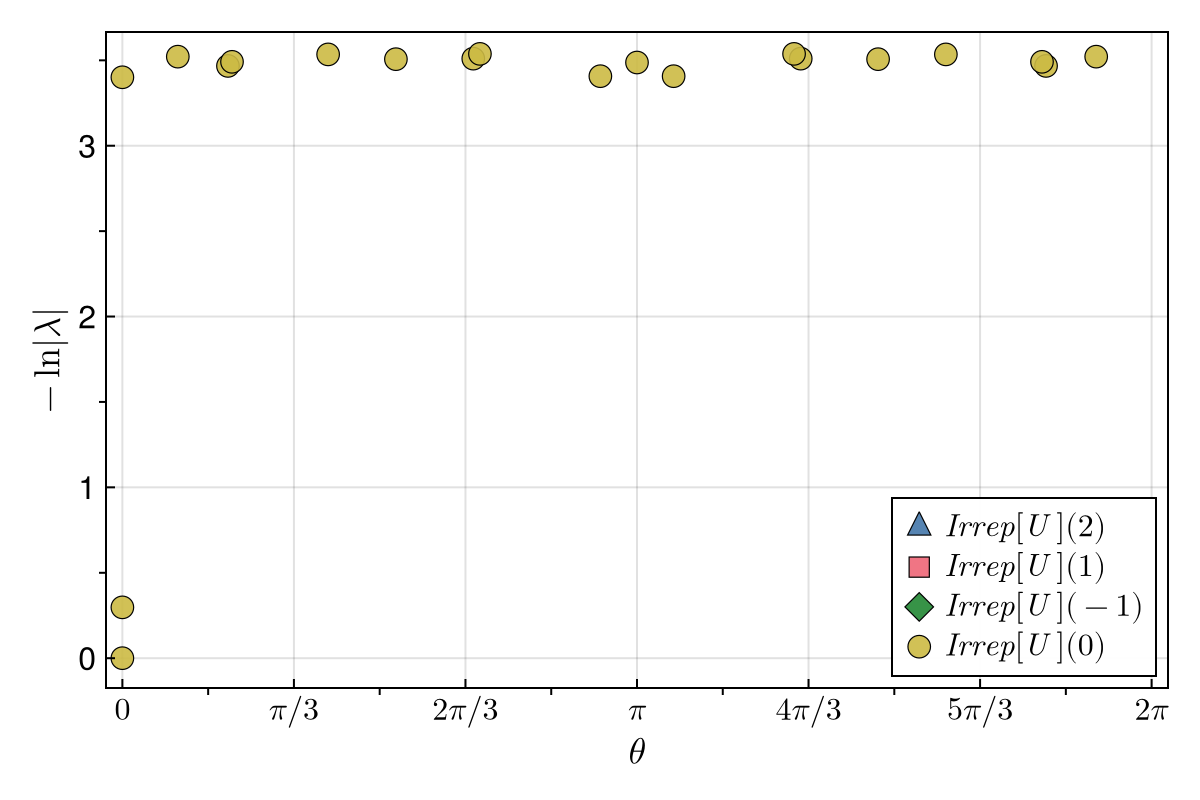

In [25]:
logTransferPlot(ψ; site=1, secNum=4, title="")

In [18]:
@load "JLD2depot/U1HCInfZCdata_Nx$(Nx)_Ny$(Ny)_J11.0_J20.5_D1600.jld2" st2

1-element Vector{Symbol}:
 :st2

┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 18 eigenvalues converged
│ * norm of residuals = (0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 6.56e-29, 8.92e-38, 9.07e-40, 1.89e-35, 6.45e-34, 1.01e-12, 4.67e-13)
│ * number of operations = 582
└ @ KrylovKit ~/.julia/packages/KrylovKit/jC5gU/src/eigsolve/arnoldi.jl:172
┌ Warning: correlation length failed to converge: normres = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.557976442380993e-29, 8.924167119798756e-38, 9.07463797208323e-40, 1.885951902835608e-35, 6.446898990226654e-34, 1.0058469006845285e-12, 4.667859855697151e-13]
└ @ MPSKit ~/.julia/packages/MPSKit/EfZBD/src/algorithms/toolbox.jl:83
┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 19 eigenvalues converged
│ * norm of residuals = (0.00e+00, 2.09e-94, 1.69e-103, 1.65e-91, 2.43e-87, 1.68e-93, 1.02e-71, 

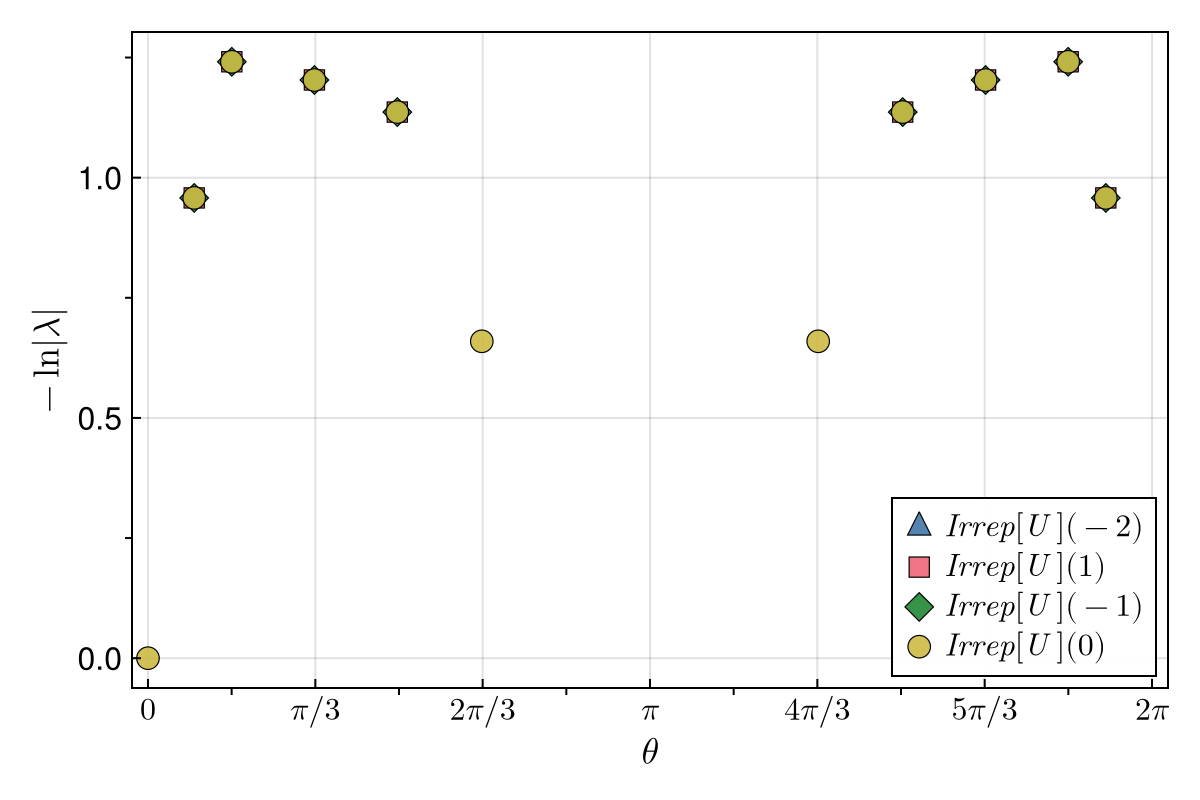

In [19]:
logTransferPlot(st2; site=1, secNum=4, title="")

In [30]:
secU1, spectU1 = sortedTransferSpectrum(st2; mix=ψ, site=1)

┌ Warning: Arnoldi eigsolve stopped without convergence after 100 iterations:
│ * 18 eigenvalues converged
│ * norm of residuals = (2.53e-71, 6.39e-66, 1.08e-61, 4.54e-61, 5.37e-50, 7.43e-56, 1.38e-48, 6.37e-45, 2.57e-43, 6.35e-42, 3.53e-44, 4.64e-32, 1.32e-30, 4.16e-27, 2.64e-28, 6.95e-35, 2.64e-23, 6.85e-33, 9.93e-15, 2.65e-22)
│ * number of operations = 676
└ @ KrylovKit ~/.julia/packages/KrylovKit/jC5gU/src/eigsolve/arnoldi.jl:172
┌ Warning: correlation length failed to converge: normres = [2.5279608726546093e-71, 6.386928868688602e-66, 1.0843155933532463e-61, 4.538470065716809e-61, 5.370029057286816e-50, 7.429364105849601e-56, 1.3815984720373134e-48, 6.373127889284951e-45, 2.57449857579746e-43, 6.347686708121516e-42, 3.5314730264719834e-44, 4.6394784789867096e-32, 1.3186671225157318e-30, 4.155258429672424e-27, 2.63905887537369e-28, 6.946770355069123e-35, 2.6351282921553378e-23, 6.851191623431567e-33, 9.93474642150477e-15, 2.645333398285524e-22]
└ @ MPSKit ~/.julia/packages/MPSKit/

(U1Irrep[0, 1, -1, 2, -2, 3, 4, -3, -4], Vector{ComplexF64}[[-0.11523593724394143 + 0.24684429652294268im, -0.0546644852414183 - 0.07716432156100535im, 0.0942546574746078 - 0.007643764334048976im, -0.019984370298853384 + 0.04280513167950761im, -0.038130437504531545 - 0.01662271653247825im, 0.03722604536791851 + 0.018555471215518645im, 0.002858307333889764 + 0.039305594864247534im, -0.031966339082336356 + 0.02304864336405126im, 0.018706421248080057 + 0.02777550524619908im, -0.033304105250952155 + 0.003494141289182762im  …  -0.018471360206372862 + 0.012883923329589285im, 0.01938866448975533 + 0.010723332484537681im, -0.020669641178115768 - 0.007976688712397298im, -0.00884872072285825 + 0.018954118032615635im, -0.004760885711531972 - 0.020159818308799232im, 0.011308016144453504 - 0.016959425299553438im, -0.018393613941291166 - 0.008176974978123464im, -0.018144838371796028 + 0.00866767959915892im, -0.01342539636291983 + 0.014920228916098299im, 0.001339837138228491 - 0.019941717928345468im]

┌ Warning: Keyword argument `bgcolor` is deprecated, use `backgroundcolor` instead.
└ @ Makie ~/.julia/packages/Makie/ux0Te/src/makielayout/blocks/legend.jl:22


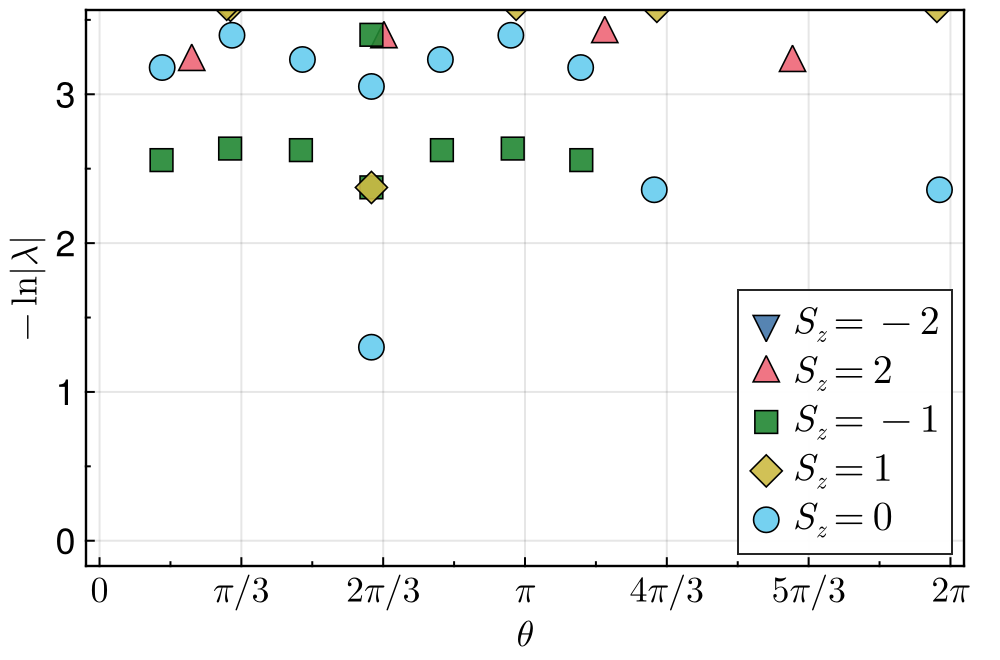

In [39]:
fig = logTransferPlotU1(st2; mix=ψ, site=1, secNum=5, secs=secU1, spect=spectU1,title="")

In [40]:
save("figs/MPS_StrCorr.png", fig)

# Fluxed states

In [ ]:
xi60s = [1.516339205540359,
      1.5527831431412165,
      1.6631485065097984,
      1.843904572006701,
      2.102952933731216,
      2.470655847455936,
      2.109267648011838,
      1.8507361924116104,
      1.6677895793950168,
      1.554354933198477,
      1.5150262633817169,
  ];
xi61s = [1.0439716840531952,
      1.0364378321380274,
      1.0138819199183906,
      0.9768808834096973,
      0.9530284997129135,
      0.9618993849288842,
      0.9530091400929963,
      0.9763949359124249,
      1.0133179428547079,
      1.0358619678805532,
      1.0437064607945878,
  ];
xi601 =[1.0439328879762608, 1.0486286120877135, 1.0618031010167293, 1.0796972317836318, 1.091100846088748, 1.2626998335931323, 1.091100846088748, 1.0796972317836318, 1.0618031010167293, 1.0486286120877135, 1.0439328879762608]

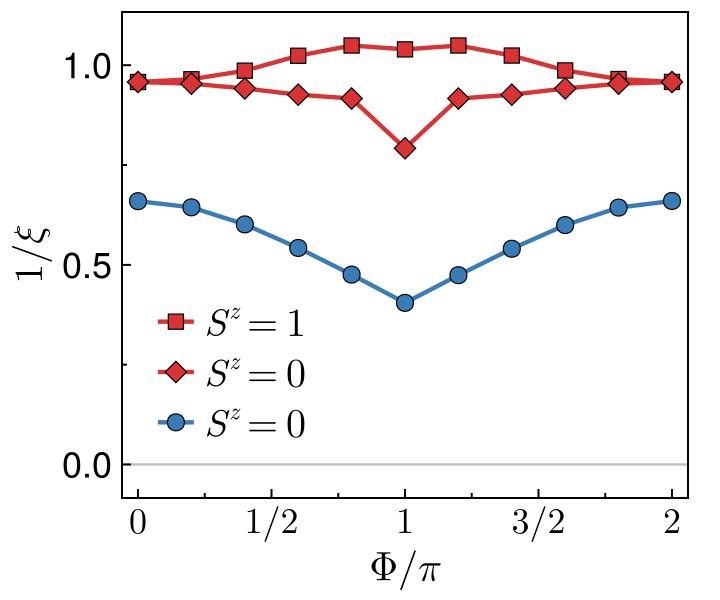

CairoMakie.Screen{IMAGE}


In [10]:
flux_xi = range(0, 1; length = length(xi60s))
xi0_inv = 1 ./ xi60s
xi1_inv = 1 ./ xi61s
xi_inv_all = vcat(xi0_inv, xi1_inv, 0.0)
xipad = 0.08 * max(maximum(xi_inv_all) - minimum(xi_inv_all), eps(Float64))

fig_xi = Figure(
    size = (360, 300),
    figure_padding = (6, 16, 6, 6),
    fonts = (; regular = "Computer Modern", bold = "Computer Modern"),
)

ax_xi = Axis(fig_xi[1, 1],
    xlabel = L"\Phi / \pi",
    ylabel = L"1 / \xi",
    xticks = (0:0.25:1, [L"0", L"1/2", L"1", L"3/2", L"2"]),
    limits = (-0.03, 1.03, minimum(xi_inv_all) - xipad, maximum(xi_inv_all) + xipad),
    xgridvisible = false,
    ygridvisible = false,
    xtickalign = 1,
    ytickalign = 1,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xminortickalign = 1,
    yminortickalign = 1,
    spinewidth = 1.0,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
)

hlines!(ax_xi, [0.0];
    color = flux_colors.guide,
    linewidth = 1.2,
)



scatterlines!(ax_xi, flux_xi, xi1_inv;
    color = flux_colors.col_fit,
    marker = :rect,
    markersize = 12,
    linewidth = 2.2,
    strokecolor = :black,
    strokewidth = 0.6,
    label = L"S^z = 1",
)

scatterlines!(ax_xi, flux_xi, 1 ./ xi601;
    color = flux_colors.col_fit,
    marker = :diamond,
    markersize = 12,
    linewidth = 2.2,
    strokecolor = :black,
    strokewidth = 0.6,
    label = L"S^z = 0",
)

scatterlines!(ax_xi, flux_xi, xi0_inv;
    color = flux_colors.col_data,
    marker = :circle,
    markersize = 12,
    linewidth = 2.2,
    strokecolor = :black,
    strokewidth = 0.6,
    label = L"S^z = 0",
)

axislegend(ax_xi;
    position = (0.03, 0.1),
    labelsize = 20,
    framevisible = false,
    patchsize = (18, 12),
)

display(fig_xi)

In [39]:
save("figs/MPS_fluxedYC12_xi.png", fig_xi)

In [18]:
# YC12
xi0s = [1.1430217125358733, 1.6731230557277583, 2.159941969667789, 2.470655847455936, 2.748013037002677]
xi1s = [0.6524546214666388, 0.7504618431175484, 0.8931083225763508, 0.9618993849288842, 1.0244056941137922]
Ss = [2.456990524135211, 2.7103968987622524, 2.8643625033353333, 2.9298995771385146, 2.978180171303176]

Ds = [400, 800, 1200, 1600, 2000];

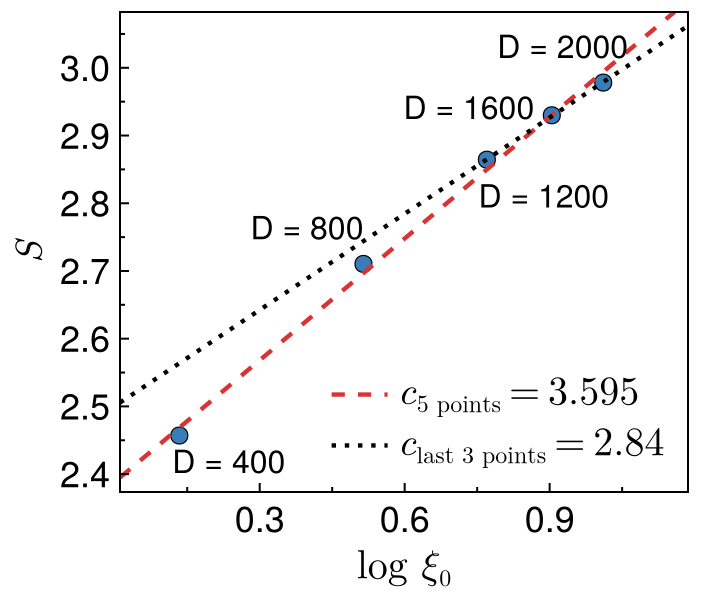

CairoMakie.Screen{IMAGE}


In [24]:
xvals = Float64.(xi0s)
logxi = log.(xvals)
yvals = Float64.(Ss)

A = hcat(logxi ./ 6, ones(length(logxi)))
c_fit, a_fit = A \ yvals
last3 = (length(logxi) - 2):length(logxi)
A_last3 = hcat(logxi[last3] ./ 6, ones(length(last3)))
c_fit_last3, a_fit_last3 = A_last3 \ yvals[last3]
xrange = max(maximum(logxi) - minimum(logxi), eps(Float64))
yrange = max(maximum(yvals) - minimum(yvals), eps(Float64))
xpad_left = 0.14 * xrange
xpad_right = 0.20 * xrange
ypad = 0.20 * yrange
xlims = (minimum(logxi) - xpad_left, maximum(logxi) + xpad_right)
ylims = (minimum(yvals) - 0.16 * yrange, maximum(yvals) + ypad)

logxi_fit = range(xlims[1], xlims[2]; length = 300)
S_fit = (c_fit / 6) .* logxi_fit .+ a_fit
logxi_fit_last3 = range(xlims[1], xlims[2]; length = 300)
S_fit_last3 = (c_fit_last3 / 6) .* logxi_fit_last3 .+ a_fit_last3

fig_S_xi = Figure(
    size = (360, 300),
    figure_padding = (6, 16, 6, 6),
    fonts = (; regular = "Computer Modern", bold = "Computer Modern"),
)

ax_S_xi = Axis(fig_S_xi[1, 1],
    xlabel = L"\log\ \xi_0",
    ylabel = L"S",
    limits = (xlims..., ylims...),
    xgridvisible = false,
    ygridvisible = false,
    xtickalign = 1,
    ytickalign = 1,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xminortickalign = 1,
    yminortickalign = 1,
    spinewidth = 1.0,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
)

scatter!(ax_S_xi, logxi, yvals;
    color = flux_colors.col_data,
    marker = :circle,
    markersize = 12,
    strokecolor = :black,
    strokewidth = 0.6,
)

lines!(ax_S_xi, logxi_fit, S_fit;
    color = flux_colors.col_fit,
    linewidth = 2.2,
    linestyle = :dash,
    label = L"c_{5\ \mathrm{points}} = %$(round(c_fit, digits = 3))",
)

lines!(ax_S_xi, logxi_fit_last3, S_fit_last3;
    color = :black,
    linewidth = 2.2,
    linestyle = :dot,
    label = L"c_{\mathrm{last}\ 3\ \mathrm{points}} = %$(round(c_fit_last3, digits = 3))",
)

label_dx = [0.25, -0.0, -0.02, -0.35, -0.25] .* xrange
label_dy = [-0.02, 0.05, -0.05, -0.03, 0.05] .* yrange
label_align = [(:right, :top), (:right, :bottom), (:left, :top), (:left, :bottom), (:left, :bottom)]

for i in eachindex(Ds)
    text!(ax_S_xi, logxi[i] + label_dx[i], yvals[i] + label_dy[i];
        text = "D = $(Ds[i])",
        align = label_align[i],
        fontsize = 16,
        color = :black,
    )
end

axislegend(ax_S_xi;
    position = :rb,
    labelsize = 20,
    framevisible = false,
    patchsize = (28, 8),
)

display(fig_S_xi)

In [25]:
save("figs/MPS_fluxedYC12_S.png", fig_S_xi)